# Surviving the tail: meeting the market

In the [simulation lab](narrative_evt_simulations.ipynb) we established, on data whose ground truth we set ourselves, how incredibily hard can be to measure a tail. Here, we impact on the market. We do not know even if these is a groudn truth. Do not worry, we shall navigate this sea together!

Our guiding atlas is going to be the  **the checklist** which we produced at the end of the simulation notebook. Its nine commandments read, briefly (more or less): (i) you shall never report a tail statistic without its sample size *in the tail*; (ii) you shall always check moment existence before using a moment; (iii) you shall always ask where the tail begins, not just what its exponent is; (iv) you shall never trust a single Hill plateau; (v) you shall always report $\xi$, not $\alpha$; (vi) you shall use profile-likelihood intervals; (vii) you shall treat every concentration and shortfall measure as a lower bound; (viii) you shall score risk models on $Z_2$, not on exception counts; and (ix) you shall size on the tail, and compute the wipeout leverage explicitly.

We shall use all of this to work with S&P data and pay our debt to [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails). Namely, we wish to anwer the question: **does covariance cleaning reduce tail risk, or only variance?**

Our astute plan:

**The data (Part 0).** The same panel as the RMT lab (so that every comparison with the previous project is like for like) plus the conventions that keep our good tails intact.

**Diagnosis (Part 1).** Here we run on our own market preasimpotitc machinery (see Chapter 10 of Taleb's SCoFT): MAD/STD, max-to-sum, kurtosis under aggregation, empirical $\kappa$, excess conditional expectation, records, and the asymmetry between the two tails. 

Everything runs on `evt_lab.py`, the same module the simulation notebook used.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import importlib, evt_lab                    # we are still editing the module:
importlib.reload(evt_lab)                    # pick up edits without a kernel restart

from evt_lab import (
    garch_kesten_alpha,
    mad, mad_over_std, max_to_sum_ratio, kappa_bootstrap, kurtosis_under_aggregation,
    survival_empirical, local_alpha, excess_conditional_ratio,
    block_maxima, fit_gev, gev_return_level,
    mean_excess, exceedances, fit_gpd, gpd_profile_ci, threshold_stability, pot_var_es,
    hill, hill_plot, pickands, dedh_moment, pareto_mle_alpha, alpha_hat_moments,
    var_es_empirical, var_es_gaussian, es_var_ratio, alpha_from_es_var_ratio, es_sigma_ratio,
    extremal_index, decluster, stationary_bootstrap,
    drawdown, max_drawdown, quantile_contribution,
    sample_cov, eigh_desc, clean_cov, min_var_weights, day_scale,
)

SEED = 20260907
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3, C4 = "C0", "C1", "C2", "C3", "C4"

DATA_DIR = os.path.abspath("data")           # gitignored cache
os.makedirs(DATA_DIR, exist_ok=True)
GAUSS_MADSTD = np.sqrt(2 / np.pi)            # 0.7979, the reference we keep returning to
GAUSS_ES_SD = 2.6652                         # ES99/sigma for a Gaussian
print("toolkit loaded; cache dir:", DATA_DIR)

toolkit loaded; cache dir: /sessions/tender-modest-fermi/mnt/Quant_Preparation/EVT-FatTails-PreAsymptotics/data


## Part 0 — The data, and the rules that keep a tail alive

Three principles, inherited from the previous lab and more load-bearing here than they were there.

**1. No winsorising. Anywhere. Ever.** Every risk system in production clips or truncates extreme
observations somewhere, usually silently, usually justified as "removing outliers". In a
thin-tailed world that is a defensible variance-reduction trick. In this world **the outliers are
the subject**. Winsorising a fat tail does not clean the data, it deletes the finding.

**2. Log returns by default, net returns where money is summed.** $r = \ln(P_t/P_{t-1})$ is
additive through time, which is what we need for aggregation, drawdowns and compounding.
$(P_t - P_{t-1})/P_{t-1}$ is additive across assets, which is what we need for portfolios. Confusing
the two is a small error in the body and a large one in the tail, since the two disagree by
$O(r^2)$.

**3. Per-window completeness, never forward-filling.** A forward-filled price manufactures a zero
return followed by a double-sized one — precisely the pattern that fattens a measured tail. We
instead require a name to have a complete history over whatever window we are using, and drop it
from that window otherwise.

The universe is the previous lab's, unchanged: about 220 liquid S&P names tagged by sector, plus a
cross-asset futures panel. Keeping it identical is the point — Part 5 has to compare like with
like.

In [2]:
UNIVERSE = {
    "Info Tech": ["AAPL","MSFT","NVDA","AVGO","ORCL","CRM","ADBE","AMD","QCOM","TXN",
                  "INTC","INTU","IBM","CSCO","ACN","AMAT","MU","LRCX","KLAC","ADI",
                  "SNPS","CDNS","PANW","ANET","NOW","APH","MSI","GLW","HPQ","NXPI"],
    "Comm Svcs": ["GOOGL","META","NFLX","DIS","CMCSA","VZ","T","TMUS","CHTR","EA",
                  "TTWO","OMC"],
    "Financials": ["BRK-B","JPM","BAC","WFC","C","GS","MS","SCHW","BLK","BX","KKR",
                   "AXP","V","MA","COF","USB","PNC","TFC","BK","AIG","MET","PRU",
                   "ALL","TRV","CB","PGR","MMC","AON","SPGI","MCO","ICE","CME"],
    "Health Care": ["LLY","UNH","JNJ","ABBV","MRK","PFE","TMO","ABT","DHR","AMGN",
                    "GILD","BMY","MDT","ISRG","SYK","BSX","VRTX","REGN","CI","ELV",
                    "CVS","HUM","BDX","EW","A","IDXX","MCK","HCA","ZTS"],
    "Cons Disc": ["AMZN","TSLA","HD","MCD","NKE","SBUX","LOW","TJX","BKNG","MAR",
                  "HLT","GM","F","ROST","YUM","CMG","ORLY","AZO","EBAY","DHI",
                  "LEN","RCL"],
    "Cons Staples": ["PG","KO","PEP","COST","WMT","PM","MO","MDLZ","CL","KMB","GIS",
                     "SYY","KR","STZ","HSY","TGT","DG","DLTR","EL"],
    "Energy": ["XOM","CVX","COP","SLB","EOG","MPC","PSX","VLO","OXY","HAL","WMB",
               "KMI","OKE","DVN","BKR"],
    "Industrials": ["CAT","DE","HON","UNP","UPS","FDX","BA","LMT","RTX","NOC","GD",
                    "GE","MMM","EMR","ETN","ITW","PH","CMI","CSX","NSC","WM","RSG",
                    "PCAR","ROK","DOV","AME","URI","PWR"],
    "Materials": ["LIN","APD","SHW","ECL","FCX","NEM","NUE","DD","PPG","VMC","MLM"],
    "Utilities": ["NEE","DUK","SO","D","AEP","EXC","SRE","XEL","ED","PEG","WEC","ES"],
    "Real Estate": ["PLD","AMT","CCI","EQIX","SPG","O","PSA","WELL","DLR","AVB"],
}
SECTOR_OF = {t: s for s, ts in UNIVERSE.items() for t in ts}
TICKERS = sorted(SECTOR_OF)

CROSS_ASSET = {
    "Equity idx":  ["ES=F", "NQ=F", "YM=F", "RTY=F", "EFA", "EEM"],
    "Rates":       ["ZB=F", "ZN=F", "ZF=F", "ZT=F", "TLT", "IEF", "SHY"],
    "Credit":      ["LQD", "HYG"],
    "Metals":      ["GC=F", "SI=F", "HG=F", "GLD", "SLV"],
    "Energy":      ["CL=F", "BZ=F", "NG=F", "RB=F", "HO=F", "XLE"],
    "Ags":         ["ZC=F", "ZS=F", "ZW=F", "KC=F", "SB=F", "CC=F", "CT=F"],
    "FX":          ["6E=F", "6J=F", "6B=F", "6A=F", "6C=F", "6S=F", "DX=F", "UUP"],
    "Real assets": ["VNQ", "DBC"],
}
CLASS_OF = {t: c for c, ts in CROSS_ASSET.items() for t in ts}
XA_TICKERS = sorted(CLASS_OF)
START = "2010-01-01"

print(f"{len(TICKERS)} equity names across {len(UNIVERSE)} sectors; "
      f"{len(XA_TICKERS)} cross-asset instruments across {len(CROSS_ASSET)} classes")

220 equity names across 11 sectors; 43 cross-asset instruments across 8 classes


In [3]:
FORCE_REFRESH = False

def _download(tickers, start, label):
    try:
        import io, logging, contextlib
        import yfinance as yf
        logging.getLogger("yfinance").setLevel(logging.CRITICAL)
        with contextlib.redirect_stderr(io.StringIO()):        # yahoo failures are noisy
            raw = yf.download(tickers, start=start, auto_adjust=True,
                              progress=False, threads=True)
        px = raw["Close"] if "Close" in raw else raw
        px = px.sort_index().dropna(axis=1, how="all") if px.ndim == 2 else px.sort_index()
        if px.empty:
            raise RuntimeError("download returned nothing")
        return px
    except Exception as e:
        print(f"  [{label}] OFFLINE or download failed ({type(e).__name__}).")
        return None

def fetch(name, tickers, start, force=False):
    """Cache-first. Returns None if we have neither a cache nor a connection."""
    path = os.path.join(DATA_DIR, f"{name}.parquet")
    if not force and os.path.exists(path):
        px = pd.read_parquet(path)
        n = px.shape[1] if px.ndim == 2 else 1
        print(f"  [{name}] cache: {n} series x {len(px)} days "
              f"({px.index[0].date()} to {px.index[-1].date()})")
        return px
    px = _download(tickers, start, name)
    if px is None:
        return None
    (px.to_frame() if px.ndim == 1 else px).to_parquet(path)
    n = px.shape[1] if px.ndim == 2 else 1
    print(f"  [{name}] downloaded and cached: {n} series x {len(px)} days")
    return px

px = fetch("sp_prices", TICKERS, START, FORCE_REFRESH)
pxa = fetch("cross_asset_prices", XA_TICKERS, START, FORCE_REFRESH)
# The long index history. EVT wants exceedances, and 4,000 days do not supply many;
# Part 2 uses this when it exists and says so loudly when it does not.
spx_long = fetch("gspc_long", "^GSPC", "1927-12-30", FORCE_REFRESH)
if spx_long is None:
    print("  [gspc_long] absent -> Part 2 will run on the 2010- window and flag the fact.\n"
          "              Run this cell once with a network connection to build it.")

  [sp_prices] cache: 218 series x 4193 days (2010-01-04 to 2026-09-03)
  [cross_asset_prices] cache: 42 series x 4197 days (2010-01-04 to 2026-09-04)
  [gspc_long] cache: 1 series x 24787 days (1927-12-30 to 2026-09-04)


Now,  before a single tail is fitted we look at what the data actually contains.

Then, **we name our data objects and fix what each one is for.** There are four of them and they are not interchangeable.

In [4]:
first_valid = px.apply(lambda s: s.first_valid_index())
full = (first_valid == px.index[0]).sum()
report = pd.DataFrame({"first date": first_valid.dt.date,
                       "missing %": (100 * px.isna().mean()).round(2),
                       "sector": pd.Series(SECTOR_OF)}).sort_values("first date")

print(f"equity panel : {px.shape[1]} names x {px.shape[0]} days "
      f"({px.index[0].date()} to {px.index[-1].date()})")
print(f"               overall missing {100 * px.isna().mean().mean():.2f}%, "
      f"{full}/{px.shape[1]} names with a complete history")
print(f"not delivered: {sorted(set(TICKERS) - set(px.columns)) or 'none'}")
print("\nlatest listings — these sit out the early windows and must never be forward-filled:")
display(report.tail(6))

equity panel : 218 names x 4193 days (2010-01-04 to 2026-09-03)
               overall missing 1.75%, 200/218 names with a complete history
not delivered: ['BK', 'MMC']

latest listings — these sit out the early windows and must never be forward-filled:


,first date,missing %,sector
HLT,2013-12-12,23.68,Cons Disc
ANET,2014-06-06,26.54,Info Tech
EA,2026-07-17,99.86,Comm Svcs
AVB,2026-07-17,99.36,Real Estate
BK,NaN,NaN,Financials
MMC,NaN,NaN,Financials


**The data cleaning works.**  We remove 6 names. Of these, the last two would really create problems if forward-filled. But we are safe.

In [5]:
# ---- returns -----------------------------------------------------------------
# Log by default: additive through time, which is what aggregation, drawdowns and
# compounding need. Net where money is summed across assets (Part 5).
lr = np.log(px).diff().iloc[1:]                  # (T, N) panel log returns
nr = px.pct_change(fill_method=None).iloc[1:]    # (T, N) panel net returns
lr_xa = np.log(pxa).diff()

# ---- OBJECT 1: THE PANEL. 218 individual stocks. The primary object of this lab,
#      and the identical object the RMT lab built its correlation matrices from.
PANEL = lr

# ---- OBJECT 2: THE MARKET. ^GSPC, the S&P 500 cash index, 98 years.
#      The only series here that contains 1929, 1987 and 2008. Used whenever we
#      want "the market" rather than "a stock", and required by Part 2.
MKT = -np.log(spx_long.iloc[:, 0].dropna()).diff().dropna() if spx_long is not None else None
MKT_WIN = MKT[MKT.index >= px.index[0]] if MKT is not None else None   # matched 2010- window

# ---- OBJECTS 3 and 4: THE CONTROLS. Neither is used to draw a conclusion; both
#      exist so that claims about OBJECT 2 can be cross-checked against series with
#      different failure modes.
CTRL_FUT = -lr_xa["ES=F"].dropna()               # e-mini futures: tradeable, but 23h/day,
                                                 #   so it books crisis moves across sessions
CTRL_EW = -np.log1p(nr.mean(axis=1, skipna=True)).dropna()   # equal-weight PORTFOLIO of the panel
                                                 #   (net across assets, THEN log)

roster = pd.DataFrame(
    [["PANEL",    "218 stocks, log returns",        f"{lr.shape[1]} x {lr.shape[0]}",
      "Parts 1a, 4, 5"],
     ["MKT",      "^GSPC cash index, losses, 98y",  f"1 x {len(MKT)}" if MKT is not None else "absent",
      "Parts 1b, 2, 3"],
     ["MKT_WIN",  "^GSPC, matched 2010- window",    f"1 x {len(MKT_WIN)}" if MKT is not None else "absent",
      "Part 1 comparison"],
     ["CTRL_FUT", "ES=F e-mini futures, losses",    f"1 x {len(CTRL_FUT)}", "control only"],
     ["CTRL_EW",  "equal-weight portfolio, losses", f"1 x {len(CTRL_EW)}", "control only"]],
    columns=["name", "what it is", "shape", "used in"]).set_index("name")
display(roster)

if MKT is not None:
    common = pd.concat([MKT_WIN.rename("MKT_WIN"), CTRL_FUT.rename("CTRL_FUT"),
                        CTRL_EW.rename("CTRL_EW")], axis=1).dropna()
    print(f"the market and its two controls, on {len(common)} common days:")
    display(pd.DataFrame({
        "correlation with MKT_WIN": common.corr()["MKT_WIN"],
        "ann. vol": common.std() * np.sqrt(252),
        "worst day": common.max(),
        "worst day on": [common[c].idxmax().date() for c in common.columns],
    }).round(4))

,what it is,shape,used in
name,,,
PANEL,"218 stocks, log returns",218 x 4192,"Parts 1a, 4, 5"
MKT,"^GSPC cash index, losses, 98y",1 x 24786,"Parts 1b, 2, 3"
MKT_WIN,"^GSPC, matched 2010- window",1 x 4194,Part 1 comparison
CTRL_FUT,"ES=F e-mini futures, losses",1 x 4192,control only
CTRL_EW,"equal-weight portfolio, losses",1 x 4192,control only


the market and its two controls, on 4188 common days:


,correlation with MKT_WIN,ann. vol,worst day,worst day on
MKT_WIN,1.0000,0.1723,0.1277,2020-03-16
CTRL_FUT,0.9741,0.1733,0.1096,2020-03-16
CTRL_EW,0.9661,0.1722,0.1310,2020-03-16


Let us be very clear here about our roster:

1. **The `PANEL` is the primary object.** It is made up by the 218 individual stocks (a priori), and it is *the identical object the RMT lab used*. EVT is univariate, so we do have to choose a series, but there is no reason for that choice to displace the panel. Indeed, the panel has
no weighting decision, no roll, no index-inclusion rules, and it is made up of **218 samples of the tail question rather than one**. 

2. **`MKT` is the market, and it exists for one reason the panel cannot supply: length.** Our panel starts in 2010 and so contains no 1929, no 1987, no 2008. `^GSPC` has $24{,}786$ days back to 1928. 

3. **`CTRL_FUT` and `CTRL_EW` draw no conclusions.** They exist because these are measurements that do not share a failure mode. `ES=F` is tradeable but trades nearly 23 hours a day, so its close-to-close books a crisis across two sessions; `^GSPC` only exists 9:30-16:00 and books it in one. The equal-weight portfolio has neither roll nor index rules but is synthetic and ignores costs. All three correlate above $0.94$ and agree
on the worst day, which is what we wanted to know. They are *not* interchangeable in the tail, as the futures come out visibly thinner, purely from the overnight window.

Now, I repeat, the object this notebook is about is **the market** (`MKT`, 98 years), and specifically its tail. Let us start looking at it.

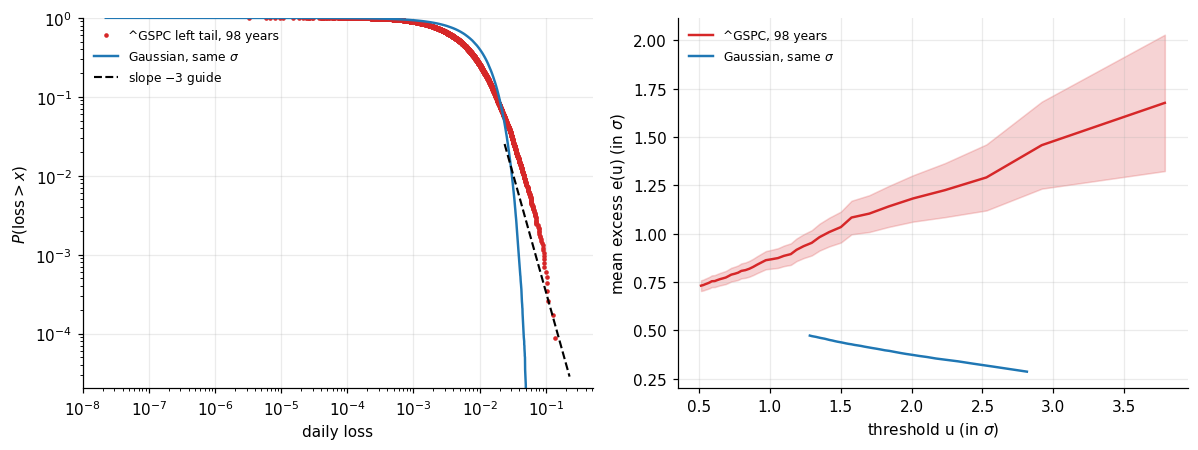

MKT: 24786 days (98 years), sigma = 0.0119
  beyond 3 sd: observed 226   a Gaussian would give 33.459
  beyond 4 sd: observed 106   a Gaussian would give 0.785
  beyond 5 sd: observed  56   a Gaussian would give 0.007
  beyond 6 sd: observed  29   a Gaussian would give 0.000
  worst: 22.90% = 19.2 sd   (a Gaussian's largest in 24786 draws would be about 4.1 sd)
  mean-excess slope: market +0.297   Gaussian -0.124


In [6]:
L0 = MKT.values                                     # THE MARKET, 98 years, losses
sd0 = L0.std()

fig, (ax1, ax2) = plt.subplots(1, 2)
xs_, s_ = survival_empirical(L0[L0 > 0])
ax1.loglog(xs_, s_, "o", ms=2, color=C3, label="^GSPC left tail, 98 years")
gl = np.abs(np.random.default_rng(3).standard_normal(400_000) * sd0)
xg, sg = survival_empirical(gl)
ax1.loglog(xg, sg, "-", lw=1.6, color=C0, label=f"Gaussian, same $\\sigma$")
grid = np.logspace(np.log10(2 * sd0), np.log10(L0.max()), 50)
ax1.loglog(grid, (grid / (2 * sd0)) ** -3.0 * float(np.mean(L0 > 2 * sd0)),
           "--", lw=1.4, color="k", label=r"slope $-3$ guide")
ax1.set(xlabel="daily loss", ylabel=r"$P(\mathrm{loss} > x)$", ylim=(1 / len(L0) / 2, 1))
ax1.legend(fontsize=8)

u_, e_, se_, n_ = mean_excess(L0, np.quantile(L0, np.linspace(.80, .995, 40)))
ax2.plot(u_ / sd0, e_ / sd0, "-", color=C3, lw=1.6, label="^GSPC, 98 years")
ax2.fill_between(u_ / sd0, (e_ - 2 * se_) / sd0, (e_ + 2 * se_) / sd0, color=C3, alpha=.2)
ug, eg, _, _ = mean_excess(gl, np.quantile(gl, np.linspace(.80, .995, 40)))
ax2.plot(ug / sd0, eg / sd0, "-", color=C0, lw=1.6, label="Gaussian, same $\\sigma$")
ax2.set(xlabel=r"threshold u (in $\sigma$)", ylabel=r"mean excess e(u) (in $\sigma$)")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

from scipy.stats import norm as _n
print(f"MKT: {len(L0)} days ({len(L0)/252:.0f} years), sigma = {sd0:.4f}")
for m in (3, 4, 5, 6):
    print(f"  beyond {m} sd: observed {int((L0 > m*sd0).sum()):>3}   "
          f"a Gaussian would give {len(L0)*_n.sf(m):.3f}")
print(f"  worst: {100*L0.max():.2f}% = {L0.max()/sd0:.1f} sd   "
      f"(a Gaussian's largest in {len(L0)} draws would be about 4.1 sd)")
print(f"  mean-excess slope: market {np.polyfit(u_/sd0, e_/sd0, 1)[0]:+.3f}   "
      f"Gaussian {np.polyfit(ug/sd0, eg/sd0, 1)[0]:+.3f}")

The plot above show **the market, over ninety-eight years and how fat tailed is it.** The Gaussian with the *same variance* falls off a cliff whilst the data do not. The data seem to follow more the guiding $\alpha = 3$ slope if anything else.

To be more specific, we can just look at the counts. In $24{,}786$ days we see **$226$ losses beyond $3\sigma$** where a Gaussian allows $33$, **$106$ beyond $4\sigma$** against $0.8$, and **$56$ beyond $5\sigma$** against $0.007$. That last is a once-in-four-hundred-year event under the Gaussian and there are fifty-six of them. The worst day is $19.2\sigma$.

**The right panel is the mean excess plot which we always appreciate (lovely, really)** In such a plot, a GPD tail has $e(u) = (\beta + \xi u)/(1-\xi)$, linear in $u$ with slope $\xi/(1-\xi)$: flat means exponential, downward means a finite endpoint, upward means heavy. The market slopes go *up* ($+0.297$), roughly linearly from about $2\sigma$ onward. 

Of course, remember to **not read the slope as an estimate**. Inverting $\xi/(1-\xi) = 0.297$ gives $\xi = 0.229$, i.e., $\alpha \approx 4.4$ , way thinner than the slope $-3$ guide the left panel just matched. The line was obtained across thresholds from the $80$th percentile up, so most of its leverage comes from the *body*, where the local exponent has not converged. **The exponent is a function of where you look, and a global fit looks mostly in the wrong place.**

## Part 1 — Diagnosing the market

Here, we run both on the `PANEL` and the `MKT` the preasymptotics toolkit we investigated. In particular:

| test | question | verdict |
| :-- | :-- | :-- |
| MAD/STD | is $\sigma$ inflated by extremes? | not thin-tailed |
| max-to-sum $R_n(p)$ | is the $p$-th moment usable *here*? | usability |
| kurtosis under aggregation | does the CLT bites us? | only with a fixed block count |
| empirical $\kappa$ | how much slower than $\sqrt{n}$? | biased toward thin, it gives a lower bound |
| $E[X \mid X>K]/K$ | is the tail scale-free? | flat = power law, decaying = thin |
| records | more extremes than i.i.d. allows? | weak; wide null |
| Hill, both tails | what is $\alpha$? | with error bars, and never one $k$ |

So we begin by looking at **the typical shock**. We directly run the whole battery across the cross-section of the `PANEL`. Every name gets its own $\kappa$, its own $R_4$, its own $\hat\alpha$. We then report the *distribution*, and the pooled estimate (whereever pooling is legitimate, that is).

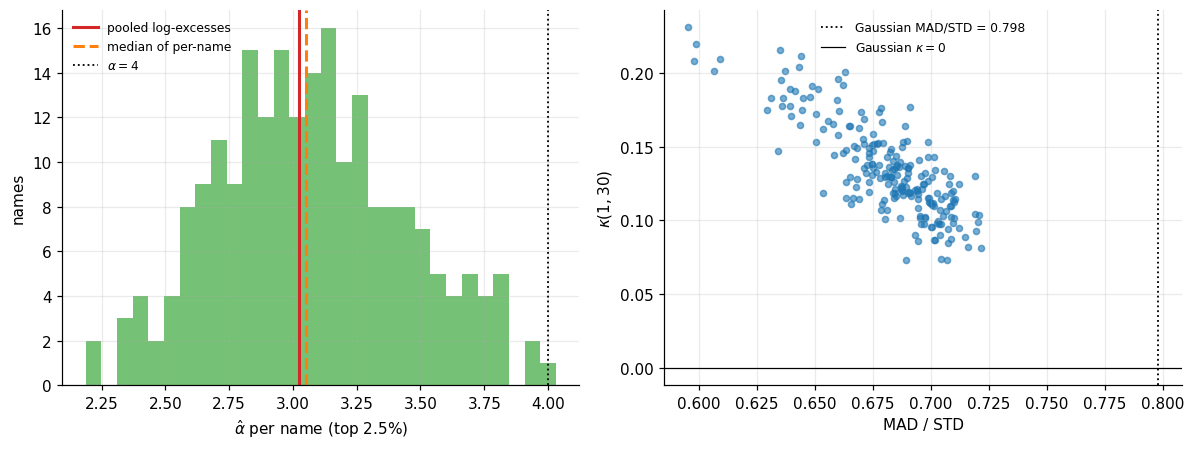

,MAD/STD,R4,alpha (Hill),ES99/sd left,"kappa(1,30)"
count,216.000,216.000,216.000,216.000,216.000
mean,0.681,0.267,3.071,4.020,0.134
std,0.024,0.177,0.373,0.268,0.031
min,0.595,0.050,2.187,3.386,0.073
10%,0.646,0.107,2.609,3.685,0.098
50%,0.685,0.201,3.052,4.016,0.129
90%,0.708,0.523,3.575,4.344,0.180
max,0.722,0.965,4.031,4.810,0.231


below the Gaussian MAD/STD of 0.7979 : 216/216
kappa(1,30) > 0                    : 216/216
R4 > 0.10 (one day owns >10% of the 4th-moment sum): 199/216
alpha < 4 (no fourth moment)       : 215/216;  alpha < 3: 97

pooled alpha over 22,276 log-excesses = 3.025 +/- 0.020
median of the per-name alphas             = 3.052
mean of the per-name alphas               = 3.071   <- do not use this

the five fattest names by R4:


,sector,R4,alpha (Hill)
ticker,,,
DHR,Health Care,0.965,3.148
OXY,Energy,0.921,2.689
SNPS,Info Tech,0.896,3.117
EQIX,Real Estate,0.883,3.065
DG,Cons Staples,0.743,2.665


In [7]:
rows, pooled_excess = [], []
for t in PANEL.columns:
    s = PANEL[t].dropna().values
    if len(s) < 1000:                                  # EA and AVB fail this, by design
        continue
    x = np.sort(np.abs(s))[::-1]
    k = max(30, len(x) // 40)                          # top 2.5% of each name
    rows.append({"ticker": t, "sector": SECTOR_OF.get(t, "?"), "n": len(s),
                 "MAD/STD": mad_over_std(s),
                 "R4": max_to_sum_ratio(s, 4)[-1],
                 "alpha (Hill)": 1.0 / (np.mean(np.log(x[:k])) - np.log(x[k])),
                 "ES99/sd left": es_sigma_ratio(-s, .01),
                 "kappa(1,30)": kappa_bootstrap(s, n=30, n0=1, reps=6_000,
                                                rng=np.random.default_rng(1))})
    pooled_excess.append(np.log(x[:k]) - np.log(x[k]))

xs = pd.DataFrame(rows).set_index("ticker")
pooled = np.concatenate(pooled_excess)
alpha_pooled = 1.0 / pooled.mean()
se_pooled = alpha_pooled / np.sqrt(pooled.size)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(xs["alpha (Hill)"], bins=30, color=C2, alpha=.65)
ax1.axvline(alpha_pooled, color=C3, lw=2, label=f"pooled log-excesses")
ax1.axvline(xs["alpha (Hill)"].median(), color=C1, lw=2, ls="--",
            label=f"median of per-name")
ax1.axvline(4, color="k", ls=":", lw=1.2, label=r"$\alpha=4$")
ax1.set(xlabel=r"$\hat\alpha$ per name (top 2.5%)", ylabel="names")
ax1.legend(fontsize=8)
ax2.scatter(xs["MAD/STD"], xs["kappa(1,30)"], s=16, c=C0, alpha=.6)
ax2.axvline(GAUSS_MADSTD, color="k", ls=":", lw=1.2, label=r"Gaussian MAD/STD = 0.798")
ax2.axhline(0, color="k", ls="-", lw=.8, label=r"Gaussian $\kappa = 0$")
ax2.set(xlabel="MAD / STD", ylabel=r"$\kappa(1,30)$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

display(xs[["MAD/STD", "R4", "alpha (Hill)", "ES99/sd left", "kappa(1,30)"]]
        .describe(percentiles=[.1, .5, .9]).round(3))
print(f"below the Gaussian MAD/STD of {GAUSS_MADSTD:.4f} : {(xs['MAD/STD'] < GAUSS_MADSTD).sum()}/{len(xs)}")
print(f"kappa(1,30) > 0                    : {(xs['kappa(1,30)'] > 0).sum()}/{len(xs)}")
print(f"R4 > 0.10 (one day owns >10% of the 4th-moment sum): {(xs['R4'] > .10).sum()}/{len(xs)}")
print(f"alpha < 4 (no fourth moment)       : {(xs['alpha (Hill)'] < 4).sum()}/{len(xs)};  "
      f"alpha < 3: {(xs['alpha (Hill)'] < 3).sum()}")
print(f"\npooled alpha over {pooled.size:,} log-excesses = {alpha_pooled:.3f} +/- {se_pooled:.3f}")
print(f"median of the per-name alphas             = {xs['alpha (Hill)'].median():.3f}")
print(f"mean of the per-name alphas               = {xs['alpha (Hill)'].mean():.3f}   <- do not use this")
print("\nthe five fattest names by R4:")
display(xs.nlargest(5, "R4")[["sector", "R4", "alpha (Hill)"]].round(3))

**We looked at two 216 names of the S&P500, and not one of them is thin. They are all fat-tailed.** 

To wit, we see that:

- **$216/216$ have MAD/STD below the Gaussian $0.798$**, with median $0.685$.
- **$216/216$ have $\kappa(1,30) > 0$**, with median $0.129$ and minimum $0.073$. Not a single name in the S&P aggregates at Gaussian speed.
- **$199/216$ have $R_n(4) > 0.10$**. This means that for the typical name a single day out of four thousand owns a fifth of its entire fourth-moment sum (median $R_4 = 0.201$).
- **$215/216$ have $\hat\alpha < 4$**. As such the fourth moment does not seem to exist for essentially the whole panel, and $97$ have $\hat\alpha < 3$.
- The median $\mathrm{ES}_{99}/\sigma$ is $4.02$ and the *minimum across all names* is $3.39$. **There is no stock in this panel for which a Gaussian expected shortfall is even approximately right.**

Moreover, from pooling $22{,}276$ log-excesses we find:

$$\hat\alpha \;=\; 3.03 \pm 0.02 .$$

Here, we draw our attention again at *how* that is computed. As we saw in the simulation lab's (PArt 5) $\hat\alpha$ is inverse-gamma distributed, so its mean is dragged by the small-$\alpha$ draws: **pool the log-excesses, never average the alphas.** Here mean-of-alphas ($3.071$) and pooled ($3.025$) differ
by only $1.5\%$ because we have many names and long histories. But on a smaller panle we would be in trouble. Furthermore, we have to stress that in computing the error of $\pm 0.02$ we are treating the $218$ names as independent. They, of course, are not. We will get back to this.

Finally, just cause it is honestly astoneshing, **the fat-tail champion deserves a look on its own.** DHR shows $R_4 = 0.965$. Think about that number for a second. One day out of $4{,}193$ accounts for **96.5%** of its fourth-moment sum, so its (if) measured kurtosis of $160$ is a description of that single day and nothing else. However, note that the Hill $\hat\alpha$, which is built on logs and on the top $2.5\%$ rather than on a fourth power, is a perfectly ordinary $3.15$. That on its own is interesting.

We can now move on to **looking at the whole market**.

EVT is a univariate game. And a long one. The market is ninety-eight years. On the other hand our panel starts in 2010 and therefore contains no 1929, no 1987, no 2008, as instead `^GSPC` does.

Of course, huge warning sign here. Ninety-eight years spans no circuit breakers, fixed commissions, the 1930s and decimalisation. Therefore, treating this whole span as one stationary sample assumes something nobody (me included) believes. We use it to *see* events the panel cannot, and we run the 2010- window alongside so that every claim can be checked against a matched period. A double check if you will.

,n,MAD/STD,R4,ES99/sd,worst day (sd),"kappa(1,30)"
series,,,,,,
^GSPC 1927- (98y),24786,0.6378,0.2522,4.3753,19.1950,0.2138
^GSPC 2010- (16y),4194,0.6606,0.2788,4.1637,11.7639,0.1813
Gaussian control,24786,0.7973,0.0076,2.6629,4.8791,0.0006


kurtosis under aggregation — with 98 years there is finally enough data to hold m fixed:


,lags,market,Gaussian control
blocks m,,,
1000,"[1, 5, 20]","[10.7, 7.53, 12.86]","[2.91, 2.93, 3.11]"
200,"[1, 5, 20, 60, 120]","[4.41, 5.06, 7.31, 6.42, 5.74]","[2.7, 2.56, 2.75, 2.87, 3.58]"


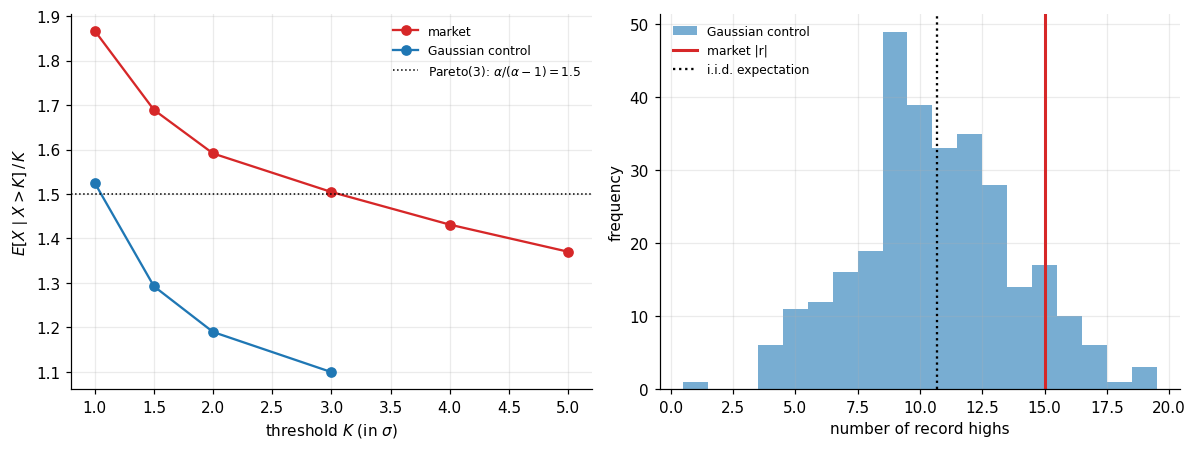

,market,Gaussian control,Pareto(3) theory
K / sigma,,,
1.0,1.867,1.525,1.5
1.5,1.689,1.293,1.5
2.0,1.591,1.190,1.5
3.0,1.504,1.099,1.5
4.0,1.431,NaN,1.5
5.0,1.370,NaN,1.5


records: market |r| = 15, i.i.d. expectation 10.70; Gaussian control median 10, 90% range [5, 16] -> market at the 93th percentile
worst day: 22.90% (19.2 sd) in 98y, vs 12.77% (11.8 sd) in the 2010- window


In [8]:
Lg = MKT.values          # OBJECT 2: the market, ^GSPC, 98 years of losses
Lm = MKT_WIN.values      # the same index restricted to the panel's 2010- window
NG, sdg = len(Lg), Lg.std()
GCL = np.random.default_rng(11).standard_normal(NG)                 # fixed Gaussian control

rows = [{"series": nm, "n": len(s), "MAD/STD": mad_over_std(s),
         "R4": max_to_sum_ratio(s, 4)[-1], "ES99/sd": es_sigma_ratio(s, .01),
         "worst day (sd)": s.max() / s.std(),
         "kappa(1,30)": kappa_bootstrap(s, n=30, n0=1, reps=40_000,
                                        rng=np.random.default_rng(1))}
        for nm, s in (("^GSPC 1927- (98y)", Lg), ("^GSPC 2010- (16y)", Lm),
                      ("Gaussian control", GCL))]
display(pd.DataFrame(rows).set_index("series").round(4))

print("kurtosis under aggregation — with 98 years there is finally enough data to hold m fixed:")
rows = [{"blocks m": B, "lags": str(lags),
         "market": np.round(kurtosis_under_aggregation(Lg, lags, blocks=B), 2),
         "Gaussian control": np.round(kurtosis_under_aggregation(GCL, lags, blocks=B), 2)}
        for B, lags in ((1000, [1, 5, 20]), (200, [1, 5, 20, 60, 120]))]
display(pd.DataFrame(rows).set_index("blocks m"))

mult = [1, 1.5, 2, 3, 4, 5]
ecr = pd.DataFrame({"K / sigma": mult,
                    "market": excess_conditional_ratio(Lg, [m * sdg for m in mult]),
                    "Gaussian control": excess_conditional_ratio(np.abs(GCL) * sdg,
                                                                 [m * sdg for m in mult]),
                    "Pareto(3) theory": [1.5] * len(mult)}).set_index("K / sigma")

def n_records(x):
    return int(np.sum(np.diff(np.maximum.accumulate(x)) > 0)) + 1

H_n = np.log(NG) + 0.5772156649
sim = np.array([n_records(np.abs(np.random.default_rng(700 + s).standard_normal(NG)))
                for s in range(300)])

fig, (ax1, ax2) = plt.subplots(1, 2)
for c_, lab in ((C3, "market"), (C0, "Gaussian control")):
    ax1.plot(mult, ecr[lab], "o-", color=c_, label=lab)
ax1.axhline(1.5, color="k", ls=":", lw=1, label=r"Pareto(3): $\alpha/(\alpha-1)=1.5$")
ax1.set(xlabel=r"threshold $K$ (in $\sigma$)", ylabel=r"$E[X \mid X>K]\,/\,K$")
ax1.legend(fontsize=8)
ax2.hist(sim, bins=np.arange(sim.min() - .5, sim.max() + 1.5), color=C0, alpha=.6,
         label="Gaussian control")
ax2.axvline(n_records(np.abs(Lg)), color=C3, lw=2, label=f"market |r|")
ax2.axvline(H_n, color="k", ls=":", lw=1.5, label=f"i.i.d. expectation")
ax2.set(xlabel="number of record highs", ylabel="frequency")
ax2.legend(fontsize=8,loc='upper right', bbox_to_anchor=(0.31, 1))
plt.tight_layout(); plt.show()
display(ecr.round(3))
print(f"records: market |r| = {n_records(np.abs(Lg))}, i.i.d. expectation {H_n:.2f}; Gaussian control "
      f"median {np.median(sim):.0f}, 90% range [{np.percentile(sim,5):.0f}, {np.percentile(sim,95):.0f}] "
      f"-> market at the {100*np.mean(sim <= n_records(np.abs(Lg))):.0f}th percentile")
print(f"worst day: {100*Lg.max():.2f}% ({Lg.max()/sdg:.1f} sd) in 98y, "
      f"vs {100*Lm.max():.2f}% ({Lm.max()/Lm.std():.1f} sd) in the 2010- window")

A lot of results. Let us go through them slowly (I also get lost if not!)

**1. $\kappa$ understates how slow the convergence is.** The bootstrap $\kappa$ resamples days that happened, so it cannot see the days that did not. Thus, it is biased toward thin tails. The 16-year window gives $\kappa(1,30) = 0.181$, the same index over 98 years gives $0.214$. **Six times the data, uniformly higher $\kappa$.** Therefore, every $\kappa$ is only a floor.

**2. Kurtoisis aggregation work well on such a big sample.** With $24{,}786$ days and $1{,}000$ blocks the Gaussian control tightens to $2.91$-$3.11$, i.e., the instrument is genuinely reliable at this sample size. It would not be $n = 4{,}192$. We see that the market gives $10.7 \to 7.53 \to 12.86$ across $k = 1, 5, 20$, i.e., **no convergence at all.** Aggregating to the monthly frequency does not make the market Gaussian.

**3. Looking at $E[X \mid X>K]/K$ gives us estimates for $\alpha$ without fitting anything.**  We now that by looking at this statistics, a Gaussian must collapse toward $1$, jsut as we see in the control $1.53 \to 1.29 \to 1.19 \to 1.10$, before running out of data entirely past $3\sigma$. A Pareto tail
would sit flat at $\alpha/(\alpha-1)$ forever. The market does neither. It reads $1.87, 1.69, 1.59, 1.50, 1.43, 1.37$ at $K = 1, 1.5, 2, 3, 4, 5\sigma$ — decaying, but *far* more slowly than the Gaussian. By inverting each value we can derive a *local* exponent of $\alpha \approx 3.0$ at $3\sigma$, $3.3$ at $4\sigma$, $3.7$ at $5\sigma$, i.e., a slow drift **upward in $\alpha$ as we move outward**. To wit, it looks like the far tail is slightly *thinner* than the near tail. 

**4. The exceedence test remains a weak one.** The market produces $15$ records against an i.i.d. expectation of $10.7$, and a Gaussian control (300 draws) whose 90% range is $[5, 16]$. This can be understood by the fact that records of excedeences grow like $\ln n$ under any continuous i.i.d. law, so the test is comparing two logarithms and has almost no power. **Not every instrument in a toolkit deserves equal weight.**

Now, the point that can make us cry a bit (and if I am sizing a portfolio I would worry about). The worst day in the 16-year window is $-12.8\%$ ($11.8\sigma$).But in the long record it is $-22.9\%$ ($19.2\sigma$). This is really bad.

Now, let us look at the asymmetry in tails, extremal indeces, and aggregation.

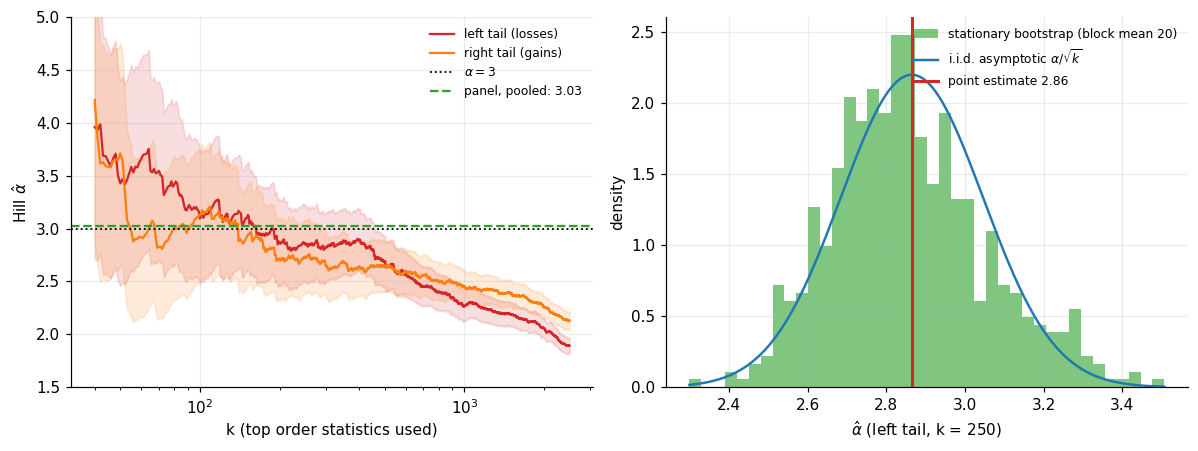

,left alpha,left se,right alpha,right se,right - left,se of diff
k,,,,,,
100,3.095,0.309,3.123,0.312,0.028,0.440
250,2.865,0.181,2.734,0.173,-0.131,0.250
500,2.691,0.120,2.650,0.118,-0.042,0.169
1000,2.264,0.072,2.453,0.078,0.188,0.106


left tail, k=250: alpha = 2.865   i.i.d. se 0.181   stationary-bootstrap sd 0.195  (90% CI [2.56, 3.22])
extremal index at the 99th percentile: 0.181 -> the 247 exceedances there are worth about 45 independent ones


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2)
kL, aL, seL = hill_plot(Lg[Lg > 0], 40, 2500)
kR, aR, seR = hill_plot(-Lg[-Lg > 0], 40, 2500)
for k_, a_, se_, c_, lab in ((kL, aL, seL, C3, "left tail (losses)"),
                             (kR, aR, seR, C1, "right tail (gains)")):
    ax1.semilogx(k_, a_, color=c_, lw=1.5, label=lab)
    ax1.fill_between(k_, a_ - 2 * se_, a_ + 2 * se_, color=c_, alpha=.15)
ax1.axhline(3, color="k", ls=":", lw=1.2, label=r"$\alpha = 3$")
ax1.axhline(alpha_pooled, color=C2, ls="--", lw=1.5,
            label=f"panel, pooled: {alpha_pooled:.2f}")
ax1.set(xlabel="k (top order statistics used)", ylabel=r"Hill $\hat\alpha$", ylim=(1.5, 5))
ax1.legend(fontsize=8)

boot = stationary_bootstrap(-Lg, 20.0, 600, np.random.default_rng(5))
al_boot = np.array([hill(-b[-b > 0], 250) for b in boot])
point = hill(Lg[Lg > 0], 250)
ax2.hist(al_boot, bins=40, color=C2, alpha=.6, density=True,
         label="stationary bootstrap (block mean 20)")
xg = np.linspace(al_boot.min(), al_boot.max(), 200)
ax2.plot(xg, np.exp(-0.5 * ((xg - point) / (point / np.sqrt(250)))**2) /
         ((point / np.sqrt(250)) * np.sqrt(2 * np.pi)), color=C0, lw=1.6,
         label=r"i.i.d. asymptotic $\alpha/\sqrt{k}$")
ax2.axvline(point, color=C3, lw=2, label=f"point estimate {point:.2f}")
ax2.set(xlabel=r"$\hat\alpha$ (left tail, k = 250)", ylabel="density")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

rows = []
for k in (100, 250, 500, 1000):
    a_l, a_r = hill(Lg[Lg > 0], k), hill(-Lg[-Lg > 0], k)
    rows.append({"k": k, "left alpha": a_l, "left se": a_l / np.sqrt(k),
                 "right alpha": a_r, "right se": a_r / np.sqrt(k),
                 "right - left": a_r - a_l, "se of diff": np.hypot(a_l, a_r) / np.sqrt(k)})
display(pd.DataFrame(rows).set_index("k").round(3))
theta = extremal_index(Lg, float(np.quantile(Lg, .99)))
print(f"left tail, k=250: alpha = {point:.3f}   i.i.d. se {point/np.sqrt(250):.3f}   "
      f"stationary-bootstrap sd {al_boot.std():.3f}  "
      f"(90% CI [{np.percentile(al_boot,5):.2f}, {np.percentile(al_boot,95):.2f}])")
print(f"extremal index at the 99th percentile: {theta:.3f} -> the "
      f"{int(0.01*NG)} exceedances there are worth about {0.01*NG*theta:.0f} independent ones")

From the plot to the left we see that **the cubic law roughly works on the market too (kinda).**

By reading the the Hill plot right to left we find that both tails sit near $3$ at small $k$ — $3.10$ left, $3.12$ right at $k = 100$ — and drift downward as $k$ grows, reaching $2.26$ and $2.45$ by $k = 1000$. That drift is what we have discussed before, i.e., the body being pulled into a tail estimate, exactly as $|t(3)|$ did in Part 4 of the simulation lab.

Furthermore, **the inter-dependence correction is not big (right plot).** Indeed, at  $k = 250$ the textbook interval is $2.87 \pm 0.181$. If we apply a resampling in geometric blocks of mean length $20$ (preserving volatility clustering) we widen the standard deviation only to $0.195$, about $8\%$. On the sixteen-year window the same exercise costs nearly $30\%$. The difference is that $98$ years contains *many* independent crises, whilst sixteen years contains essentially one, and blocking it matters enormously. **Length buys independence, not just observations.**

The extremal index is instead not softened by length. At the $99$th percentile $\theta = 0.181$, so the $247$ exceedances up there are worth roughly **$45$ independent ones**. We can safely say that 1929-33, 1987 and 2008 are not $247$ pieces of evidence about the tail, but rather they are a few dozen episodes.

Regarding symmetry instead we see that **no asymmetry emrges in the far tail**. The two tails of this market are the same size as far out as we can see,
whatever the shoulders do.

We are left with the simple question of, **does aggregating hundreds of stocks thin the tail?**

We now apply the same toolkit to both a typical S&P constituent, and the index those constituents make up. The index is an average of hundreds of names, so the naive expectation is that averaging should thin a tail.

Let us check, on a matched window so that the comparison is not contaminated by the long history's extra data.

In [10]:
cmp = pd.DataFrame({
    "typical stock (median of 216)": [
        xs["MAD/STD"].median(), xs["R4"].median(), xs["ES99/sd left"].median(), xs["kappa(1,30)"].median(), xs["alpha (Hill)"].median()],
    "the index, same window": [
        mad_over_std(Lm), max_to_sum_ratio(Lm, 4)[-1], es_sigma_ratio(Lm, .01),
        kappa_bootstrap(Lm, n=30, n0=1, reps=40_000, rng=np.random.default_rng(1)),
        hill(Lm[Lm > 0], max(30, len(Lm) // 40))],
    "the index, 98 years": [
        mad_over_std(Lg), max_to_sum_ratio(Lg, 4)[-1], es_sigma_ratio(Lg, .01),
        kappa_bootstrap(Lg, n=30, n0=1, reps=40_000, rng=np.random.default_rng(1)),
        hill(Lg[Lg > 0], 250)],
    "Gaussian": [GAUSS_MADSTD, 0.0, GAUSS_ES_SD, 0.0, np.inf],
}, index=["MAD/STD (lower = fatter)", "R4", "ES99/sd", "kappa(1,30)", "alpha (Hill)"])
display(cmp.round(4))

fat = ["MAD/STD (lower = fatter)", "R4", "ES99/sd", "kappa(1,30)"]
worse = sum((cmp.loc[m, "the index, same window"] < cmp.loc[m, "typical stock (median of 216)"])
            if m.startswith("MAD") else
            (cmp.loc[m, "the index, same window"] > cmp.loc[m, "typical stock (median of 216)"])
            for m in fat)
print(f"on a matched window, the index is FATTER than the median stock on {worse} of the {len(fat)} "
      f"fat-tail measures")
print(f"and the tail exponents agree: panel pooled {alpha_pooled:.2f}, "
      f"index {hill(Lm[Lm>0], max(30,len(Lm)//40)):.2f} (16y) / {hill(Lg[Lg>0],250):.2f} (98y)")

,typical stock (median of 216),"the index, same window","the index, 98 years",Gaussian
MAD/STD (lower = fatter),0.6847,0.6606,0.6378,0.7979
R4,0.2007,0.2788,0.2522,0.0000
ES99/sd,4.0158,4.1637,4.3753,2.6652
"kappa(1,30)",0.1295,0.1813,0.2138,0.0000
alpha (Hill),3.0521,2.8569,2.8648,inf


on a matched window, the index is FATTER than the median stock on 4 of the 4 fat-tail measures
and the tail exponents agree: panel pooled 3.03, index 2.86 (16y) / 2.86 (98y)


Well, the answer is very sad. But makes sense. **No. Aggregation does not thin the tail, and leaves the exponent exactly where it was.** I mean, with a bit of thinking this is obsvious. 

Assume we have two independent random variables $X_1$ and $X_2$ (ours are not but jsut stay with me). Now assume $X_1$ is thin-tailed and $X_2$ is fat-tailed. Then, necessarily the sum variable $X: = X_1 + X_2$ must be fat-tailed. This is because at the tail one of the two variables completely disappears. Now, if we sum instead two fat-tailed ones, the leading one is going to be (at the very far end) that with heaviest tail index. This is immediately generalised to $N$ variables of course. So no, summing fat-tailed variables does not reduce the tails. **Diversification is going to remove only the idiosyncratic thin-tailed risk!**

Here, in particular we see on the matched 2010- window, against the median of $216$ individual stocks:

| | typical stock | the index |
| :-- | --: | --: |
| MAD/STD (lower = fatter) | 0.685 | **0.661** |
| $R_4$ | 0.201 | **0.279** |
| $\mathrm{ES}_{99}/\sigma$ | 4.02 | **4.16** |
| $\kappa(1,30)$ | 0.129 | **0.181** |
| $\hat\alpha$ | 3.05 | 2.86 |

The index is fatter on **all four** preasymptotic measures (as it gets more contributions from the fattest of the names). And the tail exponent is essentially
unchanged: $3.03$ pooled across the panel against $2.86$ for the index, on either window, i.e., a difference of well under one standard error of the index estimate ($\pm 0.18$). **Averaging five hundred stocks leaves $\alpha$ where it was and makes $\kappa$ worse by two thirds with respect to the median stock.**

## Part 2 — EVT on the market

In this Part we carry on working entirely on `MKT` (i.e., the `^GSPC` cash index over $98$ years) and on `MKT_WIN`, the same index restricted to the panel's 2010- window. Here, we aim to ask **how often does a loss of a given size arrive**. Such a question needs *time*, so `MKT` it is.

This choice gives us something rare (under the assumption of fari comparison), namely **a genuine out-of-sample test with a known answer.**

Nineteen October 1987 delivered a $-22.9\%$ day. Our 2010-2026 window does not contain it, nor it does not contain anything close to it. Indeed, its own worst day is $-12.8\%$. So we can fit a tail to the modern window, extrapolate a factor of two beyond everything it has ever seen, ask "how often should a day
like 1987 happen?", and then check the answer against ninety-eight years of record. This is really cool.

In [11]:
# Same objects as Part 1, restated here so the cell stands alone.
Lg = MKT.values                                # OBJECT 2: ^GSPC, 98 years of losses
Lm = MKT_WIN.values                            # the same index, 2010- window only
NG, sdg = len(Lg), Lg.std()
W = Lg.max()                                   # the worst day on record: 1987-10-19

def wait_hill(x, k, level):
    """Years between days worse than `level`, from a pure-Pareto tail fitted above X_(k+1)."""
    xp = np.sort(x[x > 0])[::-1]
    a, u = hill(x[x > 0], k), xp[k]
    return 1.0 / ((k / len(x)) * (level / u) ** (-a)) / 252, a

def wait_pot(x, q, level):
    u = float(np.quantile(x, q)); y = x[x > u] - u
    xi, b = fit_gpd(y)
    p = (y.size / len(x)) * (1 + xi * (level - u) / b) ** (-1 / xi)
    return 1.0 / p / 252, 1 / xi

rows = []
for k in (100, 250, 500):
    t, a = wait_hill(Lm, k, W)
    rows.append({"method": f"Hill, k={k}", "fitted on": "2010- (16y)", "alpha": a, "years": t})
for k in (100, 250, 500):
    t, a = wait_hill(Lg, k, W)
    rows.append({"method": f"Hill, k={k}", "fitted on": "1927- (98y)", "alpha": a, "years": t})
for q in (.975, .99, .995):
    t, a = wait_pot(Lg, q, W)
    rows.append({"method": f"POT-GPD, u=q{100*q:g}", "fitted on": "1927- (98y)", "alpha": a, "years": t})
mx = block_maxima(Lg, 252); xi_g, mu_g, sg_g = fit_gev(mx)
p_ann = 1 - np.exp(-(1 + xi_g * (W - mu_g) / sg_g) ** (-1 / xi_g))
rows.append({"method": "GEV, annual maxima", "fitted on": "1927- (98y)",
             "alpha": 1 / xi_g, "years": 1 / p_ann})

pred = pd.DataFrame(rows).set_index("method")
pred["vs observed"] = pred["years"] / (NG / 252)
print(f"a {100*W:.2f}% day: observed ONCE in {NG/252:.0f} years of record\n")
display(pred.round(2))

a 22.90% day: observed ONCE in 98 years of record



,fitted on,alpha,years,vs observed
method,,,,
"Hill, k=100",2010- (16y),2.96,143.77,1.46
"Hill, k=250",2010- (16y),2.51,57.62,0.59
"Hill, k=500",2010- (16y),1.76,9.09,0.09
"Hill, k=100",1927- (98y),3.09,121.56,1.24
"Hill, k=250",1927- (98y),2.86,87.36,0.89
"Hill, k=500",1927- (98y),2.69,64.61,0.66
"POT-GPD, u=q97.5",1927- (98y),5.03,344.30,3.50
"POT-GPD, u=q99",1927- (98y),5.81,422.08,4.29
"POT-GPD, u=q99.5",1927- (98y),8.69,741.05,7.53


**The last column gives us the predicted return period divided by the observed $98$ years, so $1.0$ is a perfect call. Unfortunately, no one is perfect.**

But we see a series of really interesting findings:

1. **Hill gets it right from sixteen years of data (provided $k$ is small).** Fitted on 2010-2026 alone, a window whose worst day is $-12.8\%$, the pure-Pareto tail at $k = 100$ says a $-22.9\%$ day arrives every **$144$ years**. Observed: one in $98$. That is an extrapolation a factor of two beyond
the largest observation in the sample, landing within a factor of $1.5$ of the truth. However, **it degrades fast as $k$ grows**. To wit, on the short window $k=250$ gives $58$ years and $k = 500$ gives $9$, because $500$ of $4{,}194$ observations is $12\%$ of the sample, i.e., not a tail at all. On the long history the same $k$ values give $122$, $87$, $65$: all sensible, because $500$ of $24{,}786$ still *is* the tail. **The quantity that matters is $k/n$, not $k$**.

2. **GEV on annual maxima also gets it right**: $79$ years, by a completely different route, with just one observation per year, $98$ data points in total, no threshold chosen at all.

3. **The peaks-over-threshold GPD fit misses every time! And in the worst possible direction (the one that makes you feel good).** 

This is a bit of a surprise (especially given the simulation lab!). POT is the more flexible model, it is also what the literature recommends. And yet, this toad, on the one occasion we can check it against reality fails. Why, o Dea Fortuna, you hate us so much? Let us investigate!

So, let us beginning by asking: *where does the tail actually live?* From the simulation lab's we now that "which threshold" is settled by looking for the region where the shape parameter $\xi$ stops moving and the *modified scale* $\beta^* = \beta - \xi u$ goes flat. Both should be constant above the threshold where the GPD approximation becomes valid. Let us actually check,
rather than choosing the 95th percentile because it sound alright.

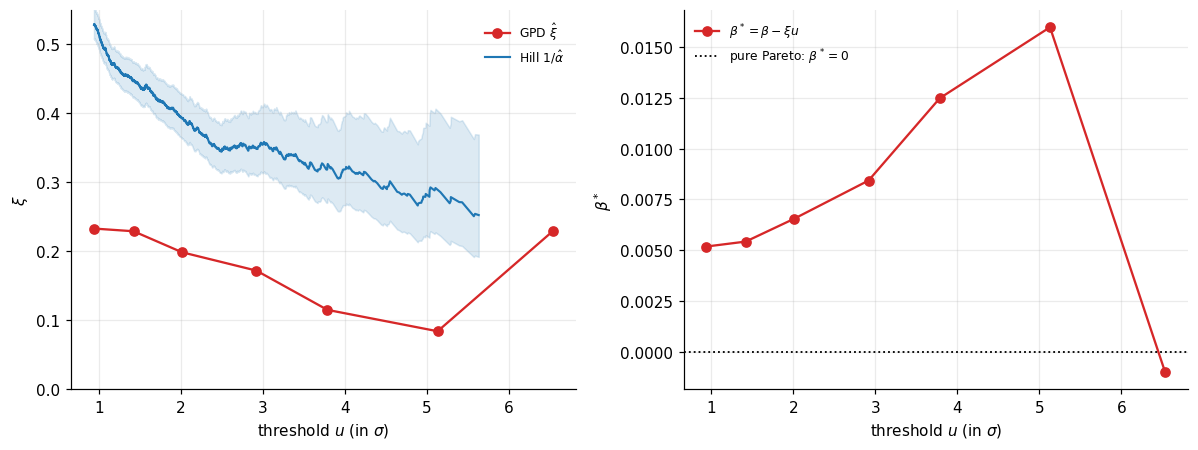

,u,u / sd,exceedances,xi,alpha = 1/xi,beta*,beta* if Pareto
quantile,,,,,,,
0.900,0.01122,0.94081,2479,0.23296,4.29255,0.00518,0.0
0.950,0.01694,1.41972,1240,0.22908,4.36533,0.00543,0.0
0.975,0.02398,2.00994,620,0.19863,5.03440,0.00655,0.0
0.990,0.03481,2.91782,248,0.17201,5.81359,0.00843,0.0
0.995,0.04516,3.78520,124,0.11505,8.69174,0.01248,0.0
0.998,0.06120,5.12983,50,0.08405,11.89775,0.01597,0.0
0.999,0.07794,6.53298,25,0.22900,4.36677,-0.00099,0.0


In [12]:
qs = [.90, .95, .975, .99, .995, .998, .999]
uu, xis, bstar, nexc = threshold_stability(Lg, np.quantile(Lg, qs), min_count=20)
stab = pd.DataFrame({"quantile": qs[:len(uu)], "u": uu, "u / sd": uu / sdg,
                     "exceedances": nexc, "xi": xis, "alpha = 1/xi": 1 / xis,
                     "beta*": bstar}).set_index("quantile")
stab["beta* if Pareto"] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(stab["u / sd"], stab["xi"], "o-", color=C3, label=r"GPD $\hat\xi$")
kk, aa, ss = hill_plot(Lg[Lg > 0], 40, 2500)
xp = np.sort(Lg[Lg > 0])[::-1]
ax1.plot(xp[kk] / sdg, 1 / aa, "-", color=C0, lw=1.4, label=r"Hill $1/\hat\alpha$")
ax1.fill_between(xp[kk] / sdg, 1 / (aa + 2 * ss), 1 / (aa - 2 * ss), color=C0, alpha=.15)
ax1.set(xlabel=r"threshold $u$ (in $\sigma$)", ylabel=r"$\xi$", ylim=(0, .55))
ax1.legend(fontsize=8)
ax2.plot(stab["u / sd"], stab["beta*"], "o-", color=C3, label=r"$\beta^* = \beta - \xi u$")
ax2.axhline(0, color="k", ls=":", lw=1.2, label=r"pure Pareto: $\beta^* = 0$")
ax2.set(xlabel=r"threshold $u$ (in $\sigma$)", ylabel=r"$\beta^*$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(stab.round(5))

We can immediately see that **the stability plot is not, well, stable. Bingo.**

From the left panel we see that $\hat\xi$ falls monotonically from $0.233$ at the $90$th percentile to $0.084$ at the $99.8$th, i.e., $\hat\alpha$ *rises* from $4.3$ to $11.9$ as we move further into the tail — before jumping back to $0.229$ on the last $25$ points, where it means nothing. A GPD tail would give a flat line. So would a Pareto one. Here, we do not see that. As a further check, the left panel puts the Hill estimate on the same axes, and they diverge as expected given the previous results on the return period measured against 1987.

The right panel explains why such a difference is present. For a *pure Pareto* tail, we have $\beta = \xi u$ exactly, so that $\beta^* = 0$ at every threshold. But this is the assumption of Hill, since it fits a one-parameter power law to the ratios $X/u$. Our $\beta^*$ is not zero. It is positive and *growing*: $+0.0054$, $+0.0084$, $+0.0125$ as $u$ rises. The excesses carry systematically more scale than a power law allows, because the GPD's second parameter is free to absorb the curvature of the near-tail. And in doing so, the fit reports a thinner $\xi$ than the far tail actually has.

**So the extra flexibility of the GPD is not free.** In-sample it fits better. However, out-of-sample, over a $6.6\times$ extrapolation in $x$, that flexibilityends up describing the shoulders and it distorts the exponent that governs everything beyond them. 

None of which means "use Hill". It means the two models disagree about a region where we have $248$ observations and are extrapolating far past all of them, and **the disagreement, not either number, is the finding.** Let us look at how uncertain each of them actually is. A number without an error means nothing after all.

As stated in the checklist, here we must **report $\xi$, not $\alpha$**, since $\alpha=1/\xi$ would turn a symmetric-looking interval into an absurd one. And **use profile-likelihood intervals**, because at these exceedance counts the Wald interval misses high far more often than it advertises.

There is also a correction we have to account for and we have been putting off. These exceedances are *clustered*. Fitting a GPD to them as though they were independent is the classic mistake, and the runs declustering from the simulation lab is the classic repair we will adopt here.

In [13]:
u = float(np.quantile(Lg, .99))
y = Lg[Lg > u] - u
xi_raw, b_raw = fit_gpd(y)
lo_raw, hi_raw = gpd_profile_ci(y, .95, grid=120, span=0.5)

peaks, _ = decluster(Lg, u, runs=5)
yd = peaks - u
xi_dc, b_dc = fit_gpd(yd)
lo_dc, hi_dc = gpd_profile_ci(yd, .95, grid=120, span=0.6)
theta = extremal_index(Lg, u)

xp = np.sort(Lg[Lg > 0])[::-1]
xi_hill = 1.0 / hill(Lg[Lg > 0], y.size)

rows = []
for nm, xi_, lo_, hi_, nn_ in (("GPD, raw exceedances", xi_raw, lo_raw, hi_raw, y.size),
                               ("GPD, declustered", xi_dc, lo_dc, hi_dc, yd.size)):
    se = np.sqrt((1 + xi_) ** 2 / nn_)
    rows.append({"fit": nm, "n": nn_, "xi": xi_,
                 "profile 95%": f"[{lo_:.3f}, {hi_:.3f}]",
                 "Wald 95%": f"[{xi_-1.96*se:.3f}, {xi_+1.96*se:.3f}]",
                 "alpha = 1/xi": 1 / xi_,
                 "alpha from profile": f"[{1/hi_:.2f}, {1/lo_:.2f}]",
                 "covers Hill's xi?": bool(lo_ <= xi_hill <= hi_)})
display(pd.DataFrame(rows).set_index("fit"))

print(f"threshold u = {u:.4f} ({u/sdg:.2f} sd), the 99th percentile")
print(f"Hill at the same k: xi = {xi_hill:.4f}  (alpha = {1/xi_hill:.3f})")
print(f"extremal index at u: {theta:.3f}  ->  mean cluster size {1/theta:.1f}; "
      f"{y.size} exceedances collapse to {yd.size} independent peaks")
print(f"\nprofile interval asymmetry (raw): upper arm {hi_raw-xi_raw:.4f} vs lower arm {xi_raw-lo_raw:.4f}")

,n,xi,profile 95%,Wald 95%,alpha = 1/xi,alpha from profile,covers Hill's xi?
fit,,,,,,,
"GPD, raw exceedances",248,0.172011,"[0.042, 0.344]","[0.026, 0.318]",5.813586,"[2.90, 23.95]",False
"GPD, declustered",139,0.206895,"[0.041, 0.464]","[0.006, 0.408]",4.833366,"[2.15, 24.69]",True


threshold u = 0.0348 (2.92 sd), the 99th percentile
Hill at the same k: xi = 0.3502  (alpha = 2.856)
extremal index at u: 0.181  ->  mean cluster size 5.5; 248 exceedances collapse to 139 independent peaks

profile interval asymmetry (raw): upper arm 0.1723 vs lower arm 0.1303


As per usual, a flurry of results: 

1. **The interval on $\xi$ makes sense whilst the interval on $\alpha$ is a (not funny) joke.** The raw fit gives $\xi = 0.172$ with a profile interval of $[0.042, 0.344]$ wide but alright. Invert it and $\alpha \in [2.90, 23.95]$. **The data are consistent with a tail exponent anywhere from "infinite fourth moment" to "essentially Gaussian for any practical purpose."** 

2. **The profile interval is visibly asymmetric**, with an upper arm of $0.172$ against a lower of $0.130$, leaning, as always, toward the heavier tail. 

3. **Declustering reconciles the two estimators.** The extremal index at this threshold is $\theta = 0.181$, i.e., the mean cluster size $5.5$, and the $248$ exceedances collapse to $139$ genuinely independent peaks. By refitting on the declustered peaks we see that $\xi$ rises from $0.172$ to $0.207$, moving toward Hill. But, do notice oh dear reader (and myself), that the important change is the interval, which widens to $[0.041, 0.464]$ and **now covers Hill's $\xi = 0.350$, which the raw interval did not. Now uncertainty is more honest.**

So, given all we know now. Let us look at the **return levels**, i.e., the loss exceeded once every $T$ years ($z_T$). It is an extrapolation with $\xi$ in the exponent, so the disagreement we have just documented shows up here magnified. Let us see.

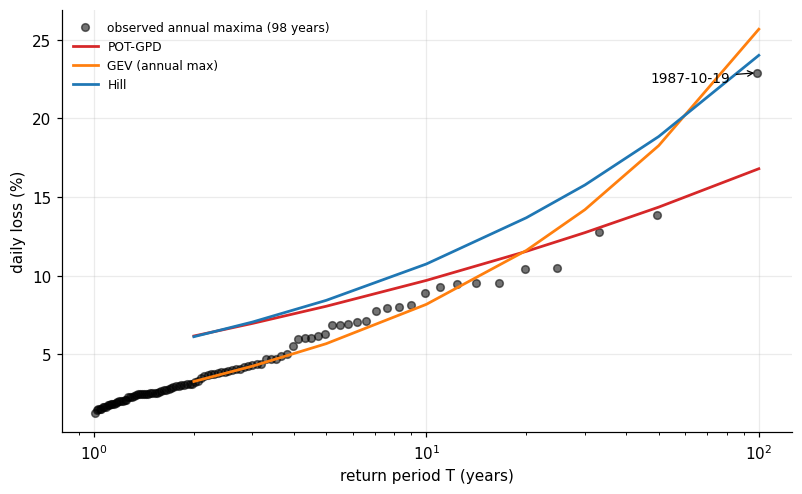

,POT-GPD,GEV (annual max),Hill
T (years),,,
2,6.17%,3.28%,6.13%
3,6.97%,4.25%,7.06%
5,8.06%,5.68%,8.44%
10,9.70%,8.18%,10.75%
20,11.55%,11.61%,13.69%
30,12.74%,14.20%,15.77%
50,14.36%,18.27%,18.85%
100,16.80%,25.67%,24.01%


observed: worst of 98 annual maxima = 22.90% at an empirical return period of 99 years


In [14]:
Ts = np.array([2, 3, 5, 10, 20, 30, 50, 100])
a_h, k_h = hill(Lg[Lg > 0], 250), 250
u_h = xp[k_h]
lev = pd.DataFrame({
    "T (years)": Ts,
    "POT-GPD": [pot_var_es(Lg, u, 1 / (t * 252))["var"] for t in Ts],
    "GEV (annual max)": [gev_return_level(xi_g, mu_g, sg_g, t) for t in Ts],
    "Hill": [u_h * ((k_h / NG) / (1 / (t * 252))) ** (1 / a_h) for t in Ts],
}).set_index("T (years)")

mx_sorted = np.sort(mx)[::-1]
emp_T = (len(mx) + 1) / np.arange(1, len(mx) + 1)          # Gumbel plotting positions

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.semilogx(emp_T, 100 * mx_sorted, "o", ms=5, color="k", alpha=.55,
            label=f"observed annual maxima ({len(mx)} years)")
for c_, lab in ((C3, "POT-GPD"), (C1, "GEV (annual max)"), (C0, "Hill")):
    ax.semilogx(Ts, 100 * lev[lab], "-", lw=1.8, color=c_, label=lab)
ax.annotate("1987-10-19", (99, 100 * W), xytext=(-70, -6), textcoords="offset points",
            fontsize=9, arrowprops=dict(arrowstyle="->", lw=.8))
ax.set(xlabel="return period T (years)", ylabel="daily loss (%)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(lev.apply(lambda s: s.map("{:.2%}".format)))
print(f"observed: worst of {len(mx)} annual maxima = {100*W:.2f}% at an empirical return period "
      f"of {(len(mx)+1)/1:.0f} years")

**That is one JUICY plot.**

At $T = 100$ years the three fits say $16.80\%$ (POT), $25.67\%$ (GEV) and $24.01\%$ (Hill). The observed rank-one annual maximum is $22.90\%$ at an empirical return period of $99$ years. GEV and Hill get it roughly right but POT sits a third below it, and its curve is visibly flattening away from the data
in the top decade of the plot.

However, we must also note where POT does *best*, namely, at $T = 2$ to $10$ years. There, it tracks the observed maxima closely, better than GEV does at $T=2$. **The GPD fit is not a bad model. It is a good model of the region it was fitted to**, which is the $99$th to $99.8$th percentile, and a poor extrapolator beyond it since the $\beta^*$ curvature it absorbed does not persist.

The practical rule that falls out is as follows: **the range over which you fit and the range over which you extrapolate should not differ by an order of magnitude.** If one needs the 100-year level, use a method that is estimating the far tail — e.g., the top few hundred order statistics, or the annual maxima — rather than one that is optimising fit over the shoulders.

Now the numbers we really need to look at.

In [15]:
rows = []
for p in (0.05, 0.01, 0.001, 0.0001):
    emp = var_es_empirical(Lg, p); gau = var_es_gaussian(Lg, p); pot = pot_var_es(Lg, u, p)
    a_, u_ = hill(Lg[Lg > 0], 250), xp[250]
    var_h = u_ * ((250 / NG) / p) ** (1 / a_)
    rows.append({"p": p, "days in tail": emp["n_tail"],
                 "VaR empirical": emp["var"], "VaR Gaussian": gau["var"],
                 "VaR POT": pot["var"], "VaR Hill": var_h,
                 "ES empirical": emp["es"], "ES Gaussian": gau["es"], "ES POT": pot["es"],
                 "ES Hill": var_h * es_var_ratio(a_),
                 "ES Hill / Gaussian": var_h * es_var_ratio(a_) / gau["es"]})
risk = pd.DataFrame(rows).set_index("p")
var_cols = ["VaR empirical", "VaR Gaussian", "VaR POT", "VaR Hill"]
var_tab = risk[var_cols].apply(lambda s: s.map("{:.2%}".format))
var_tab.insert(0, "days in tail", risk["days in tail"].astype(int))
display(var_tab)
display(risk[["ES empirical", "ES Gaussian", "ES POT", "ES Hill", "ES Hill / Gaussian"]].round(4))

,days in tail,VaR empirical,VaR Gaussian,VaR POT,VaR Hill
p,,,,,
0.0500,1240,1.69%,1.94%,1.45%,1.99%
0.0100,248,3.48%,2.75%,3.48%,3.48%
0.0010,25,7.79%,3.66%,7.56%,7.78%
0.0001,3,11.78%,4.41%,13.61%,17.39%


,ES empirical,ES Gaussian,ES POT,ES Hill,ES Hill / Gaussian
p,,,,,
0.0500,0.0290,0.0244,0.0277,0.0305,1.2526
0.0100,0.0522,0.0316,0.0522,0.0535,1.6963
0.0010,0.0999,0.0399,0.1014,0.1196,2.9947
0.0001,0.1651,0.0470,0.1746,0.2671,5.6852


These are the real numbers we have to look at when sizing a portfolio, and oh boy are they not a marvel.

**At the $1\%$ level everything agrees and nothing is really at stake.** Empirical, POT and Hill all give $\mathrm{VaR}_{99} \approx 3.5\%$ against the Gaussian's $2.75\%$. Mind you the Gaussian is $21\%$ light, which is bad but survivable. **At $p = 0.01\%$ the Gaussian says $4.41\%$ and Hill says $17.39\%$.** A factor of $3.9$. The empirical estimate, computed from the *three* observations out there, says $11.78\%$, and it cannot say more. Note aslo that POT gives $13.61\%$ here, i.e., *above* the empirical figure. This just follows from the fact that the GPD's problem is the far-tail rate, not an inability to extrapolate at all.

The $\mathrm{ES}$ columns carry the same message but harder. Expected shortfall is the average loss *given* that you are past the threshold, so it lives entirely in the region we know least about. At $p = 0.01\%$ it is $4.70\%$ under the Gaussian against $26.71\%$ under Hill, a factor of **$5.7$**. And the last column shows that the ratio grows monotonically with depth, $1.25 \to 1.70 \to 2.99 \to 5.69$. **The Gaussian is wrong in a way that worsens exactly as the stakes rise.**

## Part 3 — Clustering

Once again, we have to be clear on what we will be looking at. Really, I do not want to be pedantic. But if even I could get lost at times whilst making this, I think a recap is always good for a reader. Hence, to be clear, we will be investigatin primarily `MKT` (i.e., `^GSPC` over 98 years) and only at the end we will use the`PANEL` for a cross-check. 

We said which data we are using. Good. Very good. Now, for what? Legit question.

We begin by noting that in our investigation so far we treated exceedances as independent draws. However, they are not. And we know this. Indeed, we found the extremal index $\theta = 0.18$ at the $99$th percentile, and discovered that declustering *widened* the interval on $\xi$ in the POT fit. It is time to look at clustering more in depth. In particular, we wish to see:

1. **How much clustering is there, and is it stable?**
2. **Declustering depends on a choice of a free parameter. How much does the answer depend on it?**
3. **If we remove the clustering, does the fat tail go with it?** 

The last one is perhaps the most important. It allows us to probe whether the market's $\alpha \approx 3$ is what clustering alone would produce, or whether the conditional shocks have to be fat as well.

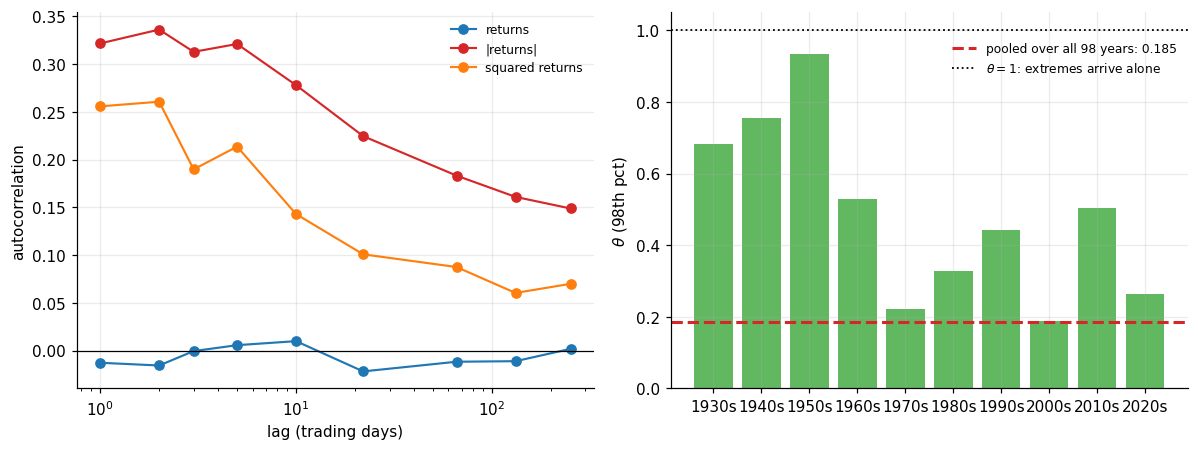

,returns,|returns|,squared returns
lag,,,
1,-0.0127,0.3215,0.2556
2,-0.0156,0.3360,0.2605
3,-0.0005,0.3127,0.1897
5,0.0057,0.3209,0.2135
10,0.0099,0.2778,0.1429
22,-0.0218,0.2245,0.1008
66,-0.0117,0.1831,0.0874
132,-0.0111,0.1609,0.0603
252,0.0018,0.1487,0.0699


,days,theta,mean cluster size
decade,,,
1930s,2496,0.682,1.466
1940s,2500,0.754,1.326
1950s,2511,0.934,1.071
1960s,2489,0.530,1.885
1970s,2526,0.221,4.517
1980s,2528,0.327,3.057
1990s,2528,0.442,2.263
2000s,2515,0.189,5.283
2010s,2516,0.504,1.985


pooled over all 24786 days: theta = 0.185  (mean cluster size 5.4)


In [16]:
MKT3 = MKT                                 # explicit: Part 3 works on object 2, ^GSPC 98y
r3 = -MKT3.values                          # signed returns (MKT stores losses)
L3 = MKT3.values                           # losses, positive
n3 = len(L3)

def acf(x, lags):
    x = np.asarray(x, float) - np.mean(x)
    v = x @ x
    return np.array([float((x[:-k] @ x[k:]) / v) for k in lags])

lags = np.array([1, 2, 3, 5, 10, 22, 66, 132, 252])
ac = pd.DataFrame({"lag": lags,
                   "returns": acf(r3, lags),
                   "|returns|": acf(np.abs(r3), lags),
                   "squared returns": acf(r3 ** 2, lags)}).set_index("lag")

theta_dec = []
d3 = pd.Series(L3, index=MKT3.index)
for dec, grp in d3.groupby(d3.index.year // 10 * 10):
    if len(grp) < 500:
        continue
    th = extremal_index(grp.values, float(np.quantile(grp.values, .98)))
    theta_dec.append({"decade": f"{dec}s", "days": len(grp), "theta": th,
                      "mean cluster size": 1 / th if th > 0 else np.inf})
theta_dec = pd.DataFrame(theta_dec).set_index("decade")
theta_all = extremal_index(L3, float(np.quantile(L3, .98)))

fig, (ax1, ax2) = plt.subplots(1, 2)
for col, c_ in (("returns", C0), ("|returns|", C3), ("squared returns", C1)):
    ax1.semilogx(lags, ac[col], "o-", color=c_, lw=1.4, label=col)
ax1.axhline(0, color="k", lw=.8)
ax1.set(xlabel="lag (trading days)", ylabel="autocorrelation")
ax1.legend(fontsize=8)
ax2.bar(theta_dec.index, theta_dec["theta"], color=C2, alpha=.75)
ax2.axhline(theta_all, color=C3, lw=2, ls="--",
            label=f"pooled over all 98 years: {theta_all:.3f}")
ax2.axhline(1.0, color="k", ls=":", lw=1.2, label=r"$\theta = 1$: extremes arrive alone")
ax2.set(ylabel=r"$\theta$ (98th pct)", ylim=(0, 1.05))
ax2.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1, 0.95))
plt.tight_layout(); plt.show()
display(ac.round(4))
display(theta_dec.round(3))
print(f"pooled over all {n3} days: theta = {theta_all:.3f}  (mean cluster size {1/theta_all:.1f})")

Two beautiful panels, and two different points. The left panel shows the autocorrelation of the returns, squared returns and absolute retursn. The right panel how the value of $\theta$ changes decade by decade. 

We "discover" the very well-known fact that the autocorrelation of *returns* is indistinguishable from zero at every lag, i.e., there is no linear predictability. However, the autocorrelation of $|{\rm returns}|$ is **still $0.15$ at $252$ days**, whilst that of ${\rm returns}^2$ is at **$0.06$**. In other words, the market is unpredictable in direction but (roughly) predictable in magnitude. **To wit, returns are nonlinearly correlated.** A direct consequence, of course, is that the i.i.d. assumption underneath every EVT fit must be removed at once.

The right panel shows something curious. By decade, $\theta$ swings from $0.93$ in the 1950s to to $0.19$ in the 2000s. And even worse, the per-decade values are not converging on anything. Wild times. In particular because **the pooled estimate over all 98 years is $0.185$, which is lower than nearly every individual decade.** Note that is not an averaging error. Indeed, pooling asks "how clustered are exceedances of the *whole-sample* 98th percentile", and those
exceedances are not spread evenly across the decades but rather pile into the volatile ones. Therefore, the pooled $\theta$ measures both (i) genuine within-episode clustering, and (ii) the concentration of extremes into particular *eras*.

The point is that declustering can repair the first problem in our fits and estimates. It is powerless about the second effect, i.e., non-stationarity of the market.

Having looked at the firs question, let us now move to the second one. Declustering keeps one peak per cluster, where clusters are separated by at least `runs`
consecutive observations below the threshold. In Part 2 we employed `runs = 5` without a specific justification. Of course that makes little sense overall. 

One has to **sweep the knob and see how much it matters.** Thus, we refit the whole Part 2 chain — $\xi$, the 100-year return level, and the implied return period of 1987 — on `MKT`, at the same $99$th-percentile threshold Part 2 used, but by varying the `runs` number.

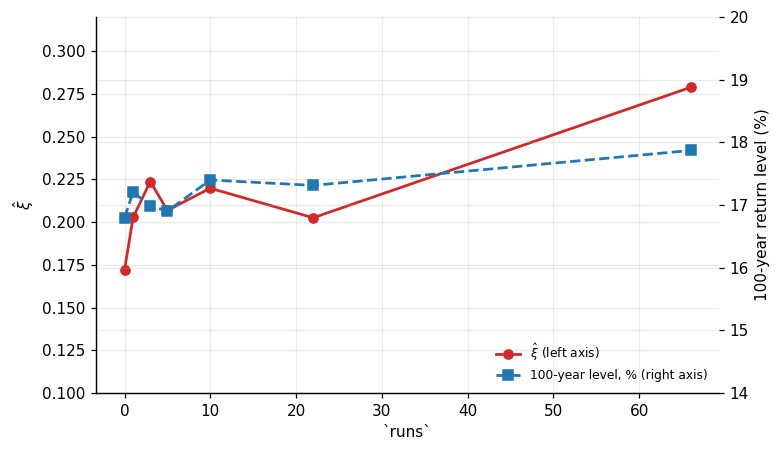

,peaks kept,xi,alpha = 1/xi,100y level (%),1987 return period (y)
runs,,,,,
0,248,0.172,5.814,16.800,422.077
1,222,0.203,4.932,17.207,333.327
3,171,0.224,4.469,16.988,322.647
5,139,0.207,4.833,16.904,337.636
10,107,0.220,4.548,17.400,280.129
22,81,0.203,4.936,17.314,287.516
66,50,0.279,3.586,17.871,211.693


(runs = 0 means no declustering at all; threshold u = 0.0348 = 2.92 sd, the 99th percentile, exactly as in Part 2)
observed: 1987 happened once in 98 years


In [17]:
u3 = float(np.quantile(L3, .99))
W3 = L3.max()                                    # 1987-10-19

def pot_chain(y, n_tot, u, n_exc):
    """xi, the 100-year level, and the implied return period of the worst day."""
    xi, b = fit_gpd(y)
    p100 = 1 / (100 * 252)
    z100 = u + (b / xi) * ((n_tot / n_exc * p100) ** (-xi) - 1)
    p_w = (n_exc / n_tot) * (1 + xi * (W3 - u) / b) ** (-1 / xi)
    return xi, z100, 1 / p_w / 252

rows = []
raw_y = L3[L3 > u3] - u3
xi_, z_, T_ = pot_chain(raw_y, n3, u3, raw_y.size)
rows.append({"runs": 0, "peaks kept": raw_y.size, "xi": xi_, "alpha = 1/xi": 1 / xi_,
             "100y level (%)": 100 * z_, "1987 return period (y)": T_})
for runs in (1, 3, 5, 10, 22, 66):
    pk, _ = decluster(L3, u3, runs=runs)
    y = pk - u3
    xi_, z_, T_ = pot_chain(y, n3, u3, y.size)
    rows.append({"runs": runs, "peaks kept": y.size, "xi": xi_, "alpha = 1/xi": 1 / xi_,
                 "100y level (%)": 100 * z_, "1987 return period (y)": T_})
dec = pd.DataFrame(rows).set_index("runs")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax2 = ax.twinx()
ax.plot(dec.index, dec["xi"], "o-", color=C3, lw=1.8, label=r"$\hat\xi$ (left axis)")
ax2.plot(dec.index, dec["100y level (%)"], "s--", color=C0, lw=1.8,
         label="100-year level, % (right axis)")
ax.set(xlabel="`runs`",
       ylabel=r"$\hat\xi$", ylim=(0.10, 0.32))
ax2.set(ylabel="100-year return level (%)", ylim=(14, 20))
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()
display(dec.round(3))
print(f"(runs = 0 means no declustering at all; threshold u = {u3:.4f} = {u3/L3.std():.2f} sd, "
      f"the 99th percentile, exactly as in Part 2)")
print(f"observed: 1987 happened once in {n3/252:.0f} years")

Our findings:

1. **$\hat\xi$ is strongly knob-dependent**. We have a value of $0.172$ with no declustering, then the value rises to $0.20$-$0.28$, i.e., a swing in $\alpha$ from $5.81$ down to $3.59$. To wit, reporting $\alpha$ from a POT fit without reporting the clustering choice means nothing.

2. **The 100-year return level barely moves at all.** We find differences going from $16.80\%$ to  max $17.87\%$. That is a $6\%$ spread against a $60\%$ spread in $\xi$. This happens because declustering both raises $\xi$ (the surviving peaks are the genuinely extreme ones) and it
lowers the exceedance *rate* $\frac{N_u}{n}$ (there are fewer of them). In the POT quantile formula

    $$z_T \;=\; u + \frac{\beta}{\xi}\left[\left(\frac{n}{N_u}\,p\right)^{-\xi} - 1\right]$$

    those two enter with opposite signs. So they kinda cancel out. Therefore, declustering is close to irrelevant if we want a *return level*, and decisive if we want a tail *exponent*.

3. **The 1987 return period just improves**. We go from $422$ years with no declustering to $212$ at `runs = 66`. Every setting still
overshoots though (no rescuing the POT fit with declustering alone). Something more is going on.

We figured out that (i) that clustering is not stable, and that (ii) how the clustering parameter affects a POT-fit number depends on the choice of the number (a lot for $\xi$, none for the 100-year return). Now we can move to the third question. Is alone clustering resposnable for fat tails? Since it flucutates wildly, probably not eh?

If the market's cubic tail is *merely* volatility arriving in bursts, then the right model is a time-varying scale with thin innovations. If instead
the tail survives the removal of clustering, then the conditional distribution is genuinely fat and no amount of volatility modelling will make it go away.

How do we test this? We stimate a one-step-ahead volatility $\sigma_t$ from data **up to $t-1$ only**, and we study the standardised residuals $z_t = r_t/\sigma_t$. We use an EWMA, which is the industry's default and has no parameters to fit beyond $\lambda$. No harm no faul.

Thanks to Kesten's theorem, we now that a GARCH turns *thin* innovations into a power law, and we can estbalish which kind. Therefore, we try just that.

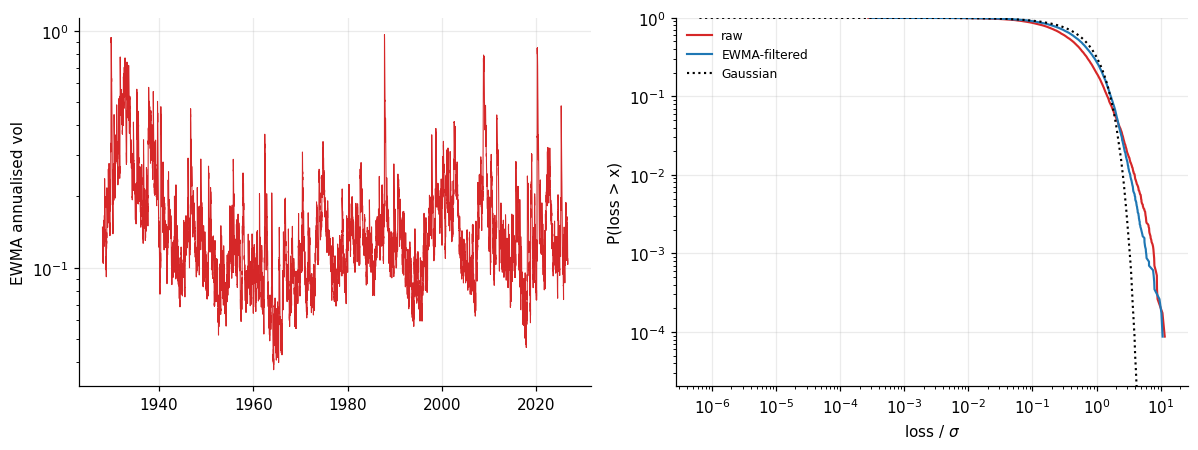

,MAD/STD,R4,"kappa(1,30)",alpha (k=250),theta (98th pct)
series,,,,,
"MKT, raw",0.6378,0.2522,0.2138,2.8648,0.1847
"MKT, EWMA-filtered",0.7395,0.0910,0.0846,3.6972,0.8783
Gaussian reference,0.7979,0.0000,0.0000,inf,1.0000


does the residual tail depend on which filter we chose?


,alpha (k=250),MAD/STD,"kappa(1,30)",theta (98th pct)
filter,,,,
EWMA lambda=0.9,3.7221,0.7393,0.0844,0.9941
EWMA lambda=0.94,3.6972,0.7395,0.0842,0.8783
EWMA lambda=0.97,3.7052,0.7349,0.0890,0.8321
EWMA lambda=0.99,3.5130,0.7207,0.1049,0.5869
rolling 22d,3.6502,0.7319,0.0916,0.8903
rolling 66d,3.6102,0.7255,0.1003,0.7796
rolling 252d,3.5500,0.7069,0.1202,0.4818


   residual alpha across all seven filters: [3.51, 3.72]   (raw series: 2.86)

can clustering with GAUSSIAN shocks alone reach the observed alpha?
   GARCH(a=0.09, b=0.9), a+b=0.990 -> alpha = 4.36
   GARCH(a=0.1, b=0.88), a+b=0.980 -> alpha = 5.56
   GARCH(a=0.12, b=0.875), a+b=0.995 -> alpha = 2.71
   GARCH(a=0.15, b=0.84), a+b=0.990 -> alpha = 2.93

   feeding back the MEASURED residual index nu = 3.70:
   GARCH(a=0.09, b=0.9) with t(3.70) shocks -> alpha = 2.62


   GARCH(a=0.1, b=0.88) with t(3.70) shocks -> alpha = 2.87

   observed raw alpha = 2.86


In [18]:
def ewma_sigma(x, lam=0.94):
    """One-step-ahead volatility: sigma_t uses returns up to t-1 only. No look-ahead."""
    s2 = np.empty(len(x)); s2[0] = x[:250].var()
    for i in range(1, len(x)):
        s2[i] = (1 - lam) * x[i - 1] ** 2 + lam * s2[i - 1]
    return np.sqrt(s2)

sig94 = ewma_sigma(r3, 0.94)
z94 = r3 / sig94                                  # standardised residuals
Lz = -z94                                         # residual losses

def battery(s, label):
    return {"series": label, "MAD/STD": mad_over_std(s),
            "R4": max_to_sum_ratio(s, 4)[-1],
            "kappa(1,30)": kappa_bootstrap(-s, n=30, n0=1, reps=40_000,
                                           rng=np.random.default_rng(1)),
            "alpha (k=250)": hill((-s)[(-s) > 0], 250),
            "theta (98th pct)": extremal_index(-s, float(np.quantile(-s, .98)))}

filt = pd.DataFrame([battery(r3, "MKT, raw"), battery(z94, "MKT, EWMA-filtered")]).set_index("series")
filt.loc["Gaussian reference"] = [GAUSS_MADSTD, 0.0, 0.0, np.inf, 1.0]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(MKT3.index, sig94 * np.sqrt(252), color=C3, lw=.7)
ax1.set(yscale="log", ylabel="EWMA annualised vol")
for s_, c_, lab in ((L3, C3, "raw"), (Lz, C0, "EWMA-filtered")):
    xs_, sv_ = survival_empirical(s_[s_ > 0] / s_.std())
    ax2.loglog(xs_, sv_, lw=1.4, color=c_, label=lab)
gl = np.abs(np.random.default_rng(4).standard_normal(400_000))
xg, sg = survival_empirical(gl)
ax2.loglog(xg, sg, lw=1.4, color="k", ls=":", label="Gaussian")
ax2.set(xlabel=r"loss / $\sigma$", ylabel="P(loss > x)", ylim=(1/n3/2, 1))
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(filt.round(4))

# ---- is the conclusion an artefact of the filter? sweep it.
def roll_sigma(x, w):
    return pd.Series(x).rolling(w).std().shift(1).bfill().values      # lagged: no look-ahead

sweep = []
for nm, sg_ in ([(f"EWMA lambda={l}", ewma_sigma(r3, l)) for l in (0.90, 0.94, 0.97, 0.99)] +
                [(f"rolling {w}d", roll_sigma(r3, w)) for w in (22, 66, 252)]):
    zz = r3 / sg_
    sweep.append({"filter": nm, "alpha (k=250)": hill((-zz)[(-zz) > 0], 250),
                  "MAD/STD": mad_over_std(zz),
                  "kappa(1,30)": kappa_bootstrap(-zz, n=30, n0=1, reps=20_000,
                                                 rng=np.random.default_rng(1)),
                  "theta (98th pct)": extremal_index(-zz, float(np.quantile(-zz, .98)))})
sweep = pd.DataFrame(sweep).set_index("filter")
print("does the residual tail depend on which filter we chose?")
display(sweep.round(4))
print(f"   residual alpha across all seven filters: [{sweep['alpha (k=250)'].min():.2f}, "
      f"{sweep['alpha (k=250)'].max():.2f}]   (raw series: {hill(L3[L3 > 0], 250):.2f})")

# ---- Kesten: can GAUSSIAN shocks reach the observed alpha with some other (a, b)?
print("\ncan clustering with GAUSSIAN shocks alone reach the observed alpha?")
for a_, b_ in ((0.09, 0.90), (0.10, 0.88), (0.12, 0.875), (0.15, 0.84)):
    print(f"   GARCH(a={a_}, b={b_}), a+b={a_+b_:.3f} -> alpha = "
          f"{garch_kesten_alpha(a_, b_, rng=np.random.default_rng(2)):.2f}")
a_meas = hill(Lz[Lz > 0], 250)
print(f"\n   feeding back the MEASURED residual index nu = {a_meas:.2f}:")
for a_, b_ in ((0.09, 0.90), (0.10, 0.88)):
    print(f"   GARCH(a={a_}, b={b_}) with t({a_meas:.2f}) shocks -> alpha = "
          f"{garch_kesten_alpha(a_, b_, nu=a_meas, rng=np.random.default_rng(2)):.2f}")
print(f"\n   observed raw alpha = {hill(L3[L3 > 0], 250):.2f}")

**GOOD WORK LADS! The filter works AND the fat tails survive. Incredible. Now let us get into the details.**

Indeed, **the filter works.** The extremal index goes from $\theta = 0.185$ to $\mathbf{0.878}$, i.e., from mean clusters of five and a half days to extremes that arrive very nearly one at a time. The EWMA has removed what it was supposed to remove. The i.i.d. assumption, fully false on the raw series, is now much closer to true on the residuals.

And yet **the fat tail survives.** We see that every fat-tail measure improves by roughly half and then stops:

| | raw | filtered ($\lambda = 0.94)| Gaussian |
| :-- | --: | --: | --: |
| MAD/STD | 0.638 | 0.740 | 0.798 |
| $R_4$ | 0.252 | 0.091 | 0 |
| $\kappa(1,30)$ | 0.214 | 0.085 | 0 |
| $\hat\alpha$ (k=250) | 2.87 | 3.70 | $\infty$ |
| $\theta$ | 0.185 | 0.878 | 1 |

The residuals are clearly **not Gaussian**. Indeed, $\kappa$ is still rather positive, the inferred tail index is $\hat\alpha = 3.70$ (still below $4$, i.e.,**the fourth moment does not exist even after conditioning on volatility**). This is clearly visible on the right panel where the filtered curve sits well inside the raw one and nowhere near the Gaussian.

We remark that here we used $\lambda = 0.94$, i.e., the RiskMetrics default for daily data. This puts $6\%$ of the weight on yesterday, has a half-life of
$11.2$ days and an effective window of $32$ days. However, our conclusion *does not* depend on the choice of (reasonable) $\lambda$. Indeed, across $\lambda \in \{0.90, 0.94, 0.97, 0.99\}$ and rolling windows of $22$, $66$ and $252$ days, the residual $\hat\alpha$ stays within $[3.51, 3.72]$. In particular, we note that **at $\theta = 0.994$ — i.e., with clustering removed about as completely as this data permits — the shocks are still fat.**

So, **what about the Kesten check?**

As we stated above, we know that GARCH does manufacture a power law out of *thin* innovations. For example, GARCH(0.09, 0.90) with Gaussian shocks produces
$\alpha = 4.36$ against our observed $2.87$. Which of course it is not great. However, this does not settle the case, of course. Indeed, if we instead consider GARCH(0.15, 0.84) we will obtain $\alpha = 2.93$. Persistence and responsiveness are substitutes for fat shocks in GARCH equation, so
the Kesten route alone cannot exclude a purely thin-shock explanation.

Nonetheless, here  **the direct measurement settles it!** We can filter to $\theta = 0.994$ and the residuals still have $\kappa = 0.084$ and $\hat\alpha = 3.72$. That is a measurement of the conditional distribution, not an inference from an assumed model. 

Now, still a couple of notes because they are important.

1. **Our data have limits.**

    Let us suppose $\sigma_t$ jumps to an enormous value for exactly one day. Then $r_t = \sigma_t z_t$ is huge with $z_t$ perfectly Gaussian, and **no filter can catch it**, because $\sigma_t$ must be predictable from information up to $t-1$. This would land in the residual and it would read as a fat shock.

    A one-day unpredictable volatility spike and a fat conditional shock are therefore **observationally equivalent at daily frequency**. Separating them needs intraday data, where realized volatility measures $\sigma_t$ *contemporaneously* instead of predicting it. We do not have these data.

    Here, waht we can say is that **conditional on any predictable volatility process estimable from daily data, the shocks are fat at every filter setting we tried, including one that removes the clustering almost entirely.** Whether that residual fatness lives in the innovations or in unpredictable one-day jumps in $\sigma_t$ is not identified here.

2. **For our purpouses, and given the methods used, the distinction does not matter operationally.**

    Both the stories we narrated above say $r_t = \sigma_t z_t$. Crucially, if the volatility spike is unpredictable from information at $t-1$, then the conditional law of tomorrow's return **given everything we know today** is *identical* under the two. So every decision that depends only on that law
    returns the same number: one-day VaR, expected shortfall, position size, margin, stop placement, leverage cap. 

    Of course, there are situation in which the the distinction *would* matter, for example:

    - **Option pricing.** This is, of course, the classical jump-versus-stochastic-volatility split, for which the two stories  imply different smile dynamics, different implied-vol term structures, and different hedging errors.
    - **Whether better forecasting has headroom.** Indeed, if the fatness is irreducibly in the shocks, improving the volatility model has a ceiling. If $\sigma_t$ really is jumping, a richer information set might make some jumps partially forecastable. 
    - **Intraday de-risking.** Here, a volatility spike may escalate visibly during the session.

    Note, that all three require capability beyond daily closes. Overall, the point is: **does the distinction change the conditional distribution of something I will act on?** If two models give the same predictive law for every decision-relevant quantity, the difference is metaphysical *for this purpose*, however real it may be for someone with different data. Fundamentally, **this is also the argument for doing any of this with EVT rather than with a parametric model.** EVT looks at the *tail* and not at the mechanism behind it. EVT does not care what generated the exceedances. A GARCH-$t$ or a
    stochastic-volatility model forces a commitment to one of the two stories above. Unfortunately, we have just demonstrated, on ninety-eight years of data, that the commitment cannot be justified from daily returns.

    Parts 4-6 accordingly need the tail to *exist* and to be measurable. They do not need its parentage.

Before moving on to even greener fields, we will close up with the final check.

The `PANEL`.  In [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) we standardised each day by the *cross-sectional* scale of that day's returns across all names, and we found that the effect halved $R_4$ and no more. If the index's time-series filter and the panel's cross-sectional filter agree, that is also interesting.

In [19]:
# ---- CHECK: PANEL, cross-sectional volatility filtering (the RMT lab's route)
Xp = PANEL.dropna(axis=1, how="any")                 # complete-history names, (T, N)
A = Xp.values.T                                      # (N, T), the module convention
A_f = A / day_scale(A)                               # divide each day by that day's cross-sectional scale

def panel_row(M, label):
    r4, ms, al = [], [], []
    for i in range(M.shape[0]):
        v = np.sort(np.abs(M[i]))[::-1]
        k = max(30, len(v) // 40)
        r4.append(max_to_sum_ratio(M[i], 4)[-1])
        ms.append(mad_over_std(M[i]))
        al.append(1.0 / (np.mean(np.log(v[:k])) - np.log(v[k])))
    return {"panel": label, "median R4": np.median(r4), "median MAD/STD": np.median(ms),
            "median alpha": np.median(al), "names with alpha < 4": int(np.sum(np.array(al) < 4)),
            "of": M.shape[0]}

panel_cmp = pd.DataFrame([panel_row(A, "raw"),
                          panel_row(A_f, "day-standardised")]).set_index("panel")
print(f"PANEL: {A.shape[0]} complete-history names x {A.shape[1]} days")
display(panel_cmp.round(4))

PANEL: 199 complete-history names x 4192 days


,median R4,median MAD/STD,median alpha,names with alpha < 4,of
panel,,,,,
raw,0.2006,0.6846,3.0514,198,199
day-standardised,0.1462,0.7457,3.9400,105,199


**The panel and the market agree!** If we divide each day by the *cross-sectional* dispersion of that day's 199 returns — no time series involved at all — we then move the median name's $\hat\alpha$ from $3.05$ to $3.94$, its $R_4$ from $0.201$ to $0.146$, and its MAD/STD from $0.685$ to $0.746$. The count of names without an alleged fourth moment falls from $198/199$ to $105/199$.

Now, the index's *time-series* EWMA(\lambda = 0.94) filter moved $\hat\alpha$ from $2.87$ to $3.70$. **Two filters with nothing in common deliver only about one unit of tail exponent.** Volatility, however you measure it, it seems to account for roughly that much of the market's fat-tailedness.The rest is in the shocks.

## Part 4 — Can a portfolio avoid fat-tail land?

Now we look at the `PANEL`, i.e., the 218 individual stocks then restricted to the 199 with a complete history so that a correlation matrix is well defined. `MKT` plays vonly a very minor role here at the very beginning.

Given that conditional shocks *are fat*, we know that these cannot be diversified away. But than fat-tailness must *live somewhere* in the panel, and a portfolio is a direction in that panel. So: **which directions are the fat ones, and does any standard RMT portfolio building manage to avoid them?**

The problem is complex. Hence we break it down. A four-forked attack, if you will.

1. **We decompose.** We split each stock into its estimated market component and its residual. Which half carries the fat?
2. **We look at the size curve.** To wit, what happens to $\alpha$, $\kappa$ and $\mathrm{ES}_{99}/\sigma$ as a portfolio grows from one name to two hundred, and where does it stop changing?
3. **We look at Tail dependence.** Namely, the probability that one name is extreme *given* another is. All measured against what a Gaussian copula with the same correlation would predict. Note, that this is the quantity linear correlation cannot see.
4. **We investigate the spectrum.** We project the panel onto each eigenvector of its sample correlation matrix and measure the tail exponent along each direction. Interstignly, we remark that a minimum-variance portfolio is a very specific direction and we are about to find out what kind of world it lives in. Whether it is mediocristan or extremistan.

So, **is the fat in the market factor or in the residuals?**

In [20]:
# PANEL, restricted to complete histories and aligned to MKT so the regression is clean
Xp4 = PANEL.dropna(axis=1, how="any")
mkt4 = (-MKT).reindex(Xp4.index).dropna()          # signed market returns
Xp4 = Xp4.loc[mkt4.index]
A4 = Xp4.values.T                                  # (N, T)
m4 = mkt4.values
N4, T4 = A4.shape

def alpha_of(v, frac=40):
    """Hill on |v|, top 1/frac of the sample — the same convention as Part 1."""
    v = np.sort(np.abs(np.asarray(v, float)))[::-1]
    k = max(30, len(v) // frac)
    return 1.0 / (np.mean(np.log(v[:k])) - np.log(v[k]))

beta = (A4 @ m4) / (m4 @ m4)                       # market beta per name
RES = A4 - np.outer(beta, m4)                      # idiosyncratic residuals
r2 = 1 - RES.var(axis=1) / A4.var(axis=1)

sub = range(0, N4, 4)                              # kappa on every 4th name: it is the slow one
dec4 = pd.DataFrame([
    {"component": "MKT (the market itself)", "alpha": alpha_of(m4),
     "kappa(1,30)": kappa_bootstrap(-m4, n=30, n0=1, reps=8_000, rng=np.random.default_rng(1)),
     "ES99/sd": es_sigma_ratio(-m4, .01)},
    {"component": "beta x market (systematic)", "alpha": np.median([alpha_of(beta[i]*m4) for i in range(N4)]),
     "kappa(1,30)": np.nan, "ES99/sd": np.nan},
    {"component": "residual (idiosyncratic)", "alpha": np.median([alpha_of(RES[i]) for i in range(N4)]),
     "kappa(1,30)": np.median([kappa_bootstrap(-RES[i], n=30, n0=1, reps=4_000,
                                               rng=np.random.default_rng(1)) for i in sub]),
     "ES99/sd": np.median([es_sigma_ratio(-RES[i], .01) for i in range(N4)])},
    {"component": "raw stock returns", "alpha": np.median([alpha_of(A4[i]) for i in range(N4)]),
     "kappa(1,30)": np.median([kappa_bootstrap(-A4[i], n=30, n0=1, reps=4_000,
                                               rng=np.random.default_rng(1)) for i in sub]),
     "ES99/sd": np.median([es_sigma_ratio(-A4[i], .01) for i in range(N4)])},
]).set_index("component")

print(f"PANEL: {N4} complete-history names x {T4} days, regressed on MKT")
print(f"median beta {np.median(beta):.3f}   median R^2 {np.median(r2):.3f}   "
      f"-> {100*(1-np.median(r2)):.0f}% of a typical name's variance is idiosyncratic")
display(dec4.round(4))

PANEL: 199 complete-history names x 4192 days, regressed on MKT
median beta 0.944   median R^2 0.339   -> 66% of a typical name's variance is idiosyncratic


,alpha,"kappa(1,30)",ES99/sd
component,,,
MKT (the market itself),3.0969,0.1765,4.1638
beta x market (systematic),3.0969,NaN,NaN
residual (idiosyncratic),3.0105,0.1662,4.0116
raw stock returns,3.0514,0.1617,4.0069


We find that **the idiosyncratic risk is not thin, and averaging does nothing to it as it is exactly as fat as everything else.**

We see in the table above (where we report median values) that a typical name has $R^2 = 0.34$ against the market, so that **two-thirds of its variance is idiosyncratic**. Since la Dea Fortuna wanted to play with us and have some fun, that two-thirds has $\alpha = 3.01$ and $\kappa = 0.166$, i.e., statistically indistinguishable from the raw returns it came from.There is no thin component to diversify *into*. Earnings surprises, downgrades, litigation, accounting restatements — any of the name-specific events are themselves power-law distributed.  

We can noe move on to look at **how fast does diversification stop helping?**

Part 1 compared one stock against two hundred. Here, we ask instead *how many names* it takes to acquire the index's tail,
which is an operational number. Very good.

We use equal-weight portfolios of $N$ randomly chosen names, with twenty draws at each $N$, and report the median.

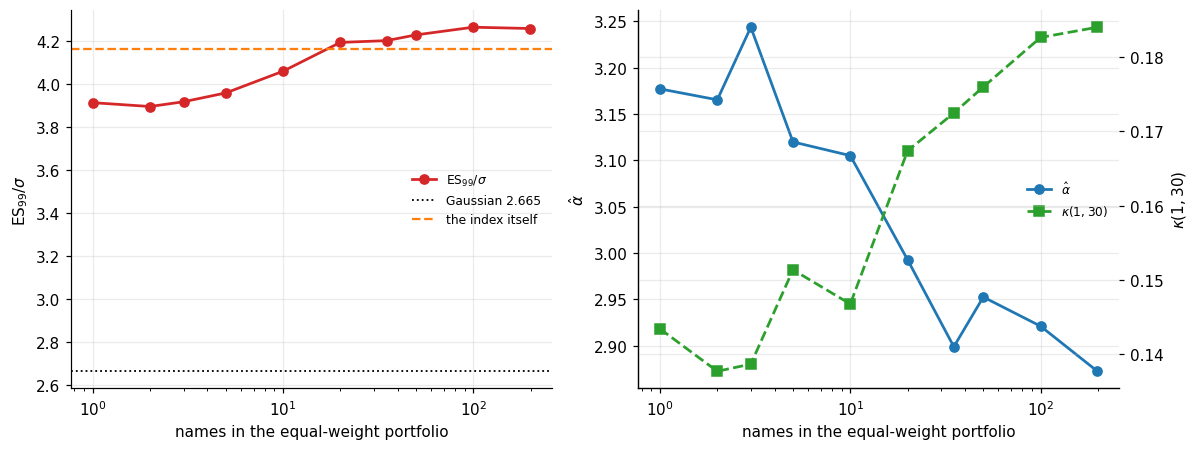

,alpha,ES99/sd,"kappa(1,30)",ann. vol
N,,,,
1,3.1769,3.9127,0.1434,0.2680
2,3.1652,3.8949,0.1377,0.2248
3,3.2435,3.9169,0.1387,0.2100
5,3.1197,3.9579,0.1514,0.1876
10,3.1050,4.0587,0.1468,0.1835
20,2.9927,4.1926,0.1674,0.1781
35,2.8989,4.2008,0.1725,0.1738
50,2.9525,4.2275,0.1760,0.1735
100,2.9211,4.2632,0.1827,0.1717


annualised vol falls 26.8% -> 17.0%  while ES99/sd rises 3.91 -> 4.26


In [21]:
rng4 = np.random.default_rng(0)
sizes = [1, 2, 3, 5, 10, 20, 35, 50, 100, N4]
rows = []
for Nn in sizes:
    al, es_, ka, vol = [], [], [], []
    for _ in range(20 if Nn < N4 else 1):
        idx = rng4.choice(N4, Nn, replace=False)
        p = A4[idx].mean(axis=0)                      # equal-weight, net-vs-log immaterial here
        al.append(alpha_of(p))
        es_.append(es_sigma_ratio(-p, .01))
        ka.append(kappa_bootstrap(-p, n=30, n0=1, reps=4_000, rng=np.random.default_rng(1)))
        vol.append(p.std() * np.sqrt(252))
    rows.append({"N": Nn, "alpha": np.median(al), "ES99/sd": np.median(es_),
                 "kappa(1,30)": np.median(ka), "ann. vol": np.median(vol)})
curve = pd.DataFrame(rows).set_index("N")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.semilogx(curve.index, curve["ES99/sd"], "o-", color=C3, lw=1.8, label=r"$\mathrm{ES}_{99}/\sigma$")
ax1.axhline(GAUSS_ES_SD, color="k", ls=":", lw=1.2, label="Gaussian 2.665")
ax1.axhline(es_sigma_ratio(MKT_WIN.values, .01), color=C1, ls="--", lw=1.5,
            label="the index itself")
ax1.set(xlabel="names in the equal-weight portfolio", ylabel=r"$\mathrm{ES}_{99}/\sigma$")
ax1.legend(fontsize=8)
ax2.semilogx(curve.index, curve["alpha"], "o-", color=C0, lw=1.8, label=r"$\hat\alpha$")
ax2b = ax2.twinx()
ax2b.semilogx(curve.index, curve["kappa(1,30)"], "s--", color=C2, lw=1.8, label=r"$\kappa(1,30)$")
ax2.set(xlabel="names in the equal-weight portfolio", ylabel=r"$\hat\alpha$")
ax2b.set(ylabel=r"$\kappa(1,30)$")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
plt.tight_layout(); plt.show()
display(curve.round(4))
print(f"annualised vol falls {100*curve.loc[1,'ann. vol']:.1f}% -> {100*curve.loc[N4,'ann. vol']:.1f}%  "
      f"while ES99/sd rises {curve.loc[1,'ES99/sd']:.2f} -> {curve.loc[N4,'ES99/sd']:.2f}")

We find out we already stated in Part 1, but with better plots. **Diversification in a fat-tail world reduces the variances and ups the tail, simultaneously.**

Annualised volatility falls from $26.8\%$ for a single name to $17.0\%$ for the full panel, and meanwhile:

- $\mathrm{ES}_{99}/\sigma$ rises **$3.91 \to 4.26$**
- $\kappa(1,30)$ rises **$0.143 \to 0.184$**
- $\hat\alpha$ falls **$3.18 \to 2.87$**

To wit, every measure of *shape* degrades monotonically while the measure of *scale* improves. The portfolio genuinely is less volatile, but each unit of volatility it carries is a worse unit than the one it started with.

Additionally, **the plateau is reached at $N \approx 20$.** We find that $\mathrm{ES}_{99}/\sigma$ runs $3.91 \to 4.19 \to 4.26$ at $N = 1, 20, 199$. Thus, we see that **$81\%$ of the total degradation has happened by the twentieth name**. Volatility behaves the same way — $26.8\% \to 17.8\% \to 17.0\%$ — which is the familiar result that thirty names is most of the diversification available.

"Thirty names is enough diversification" is reassuring when looking at the variance, and very alarming when talking about the tails. Thirty names is enough to have acquired the index's tail in full, with no further protection available at any $N$.

Why? Our first suspect is the marginals of course. A sum of *independent* regularly-varying variables the tail index of the sum is the **minimum** of the
components'. To wit, the heaviest name dominates, and our panel does contain heavier ones ($\alpha$ runs down to $2.19$). So "the portfolio is fat because a few of its constituents are very fat" could be the truth. It is the next thing to test, and we are going to do it.

To probe this question we look at the single qunatity that decides everything, i.e., **TAIL DEPENDENCE**. This is defined by 

$$\lambda_u \;=\; P\big(Y \text{ in its lower quartile}\; u \;\big|\; X \text{ in its lower quartile}\; u\big)\,.$$

Independence gives $\lambda_u = u$. A **Gaussian copula** (whatever its correlation) gives $\lambda_m \to 0$ as $q \to 0$: extremes become asymptotically independent no matter how correlated the bodies are. A $t$-copula (for example) would instead give a strictly positive limit even at zero correlation.

So $\lambda_u$ is not a re-statement of correlation. Two panels can share a correlation matrix to the last digit and differ completely here. We compute it for all $19{,}701$ pairs in `PANEL`, and benchmark each pair against **a Gaussian copula carrying that same pair's correlation**.

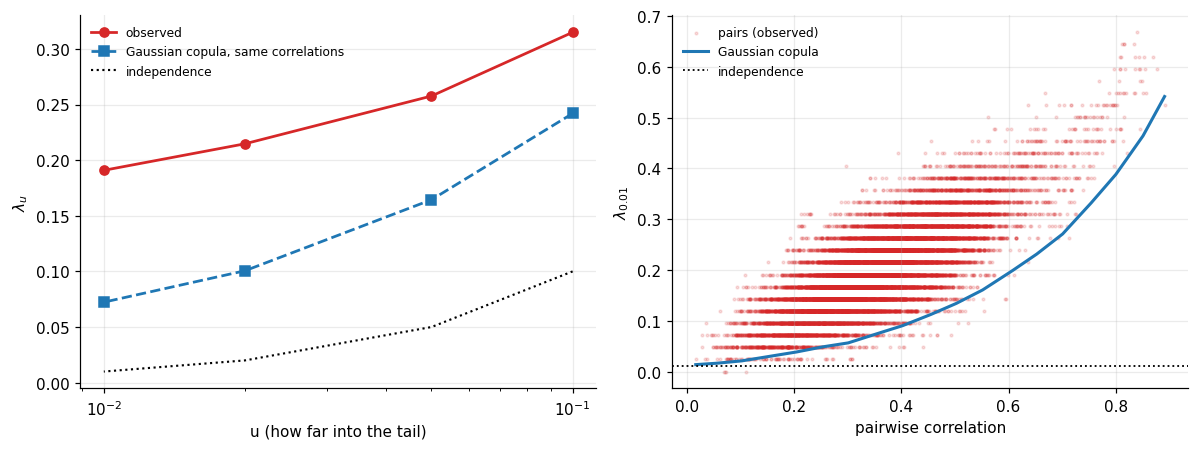

,independence,Gaussian copula (median),empirical (median),empirical / Gaussian,% pairs above Gaussian
q,,,,,
0.10,0.10,0.2419,0.3149,1.2881,99.4417
0.05,0.05,0.1644,0.2576,1.5323,99.9086
0.02,0.02,0.1006,0.2147,2.0619,99.7056
0.01,0.01,0.0723,0.1908,2.5396,99.1625


mean pairwise correlation, conditioned on the market:
   all days                 0.3559   (n = 4192)
   calmest 75%              0.2331   (n = 3144)
   worst 5% of market days  0.3786   (n = 210)

each day, how many of the 199 names are in their OWN worst 1%?
   mean per day: observed 1.95, Gaussian 2.04  (both pinned at N*u = 2.0)
   worst single day: observed 190 of 199, Gaussian 105


,observed,"Gaussian copula, same C"
days with >= this many names crashing,,
5,303,493
10,130,211
20,63,79
50,19,11
100,8,1



is it the marginals or the dependence?

and does dropping the heaviest names matter?
   drop the  0 heaviest names -> portfolio alpha 2.872, ES99/sd 4.257
   drop the  5 heaviest names -> portfolio alpha 2.879, ES99/sd 4.247
   drop the 10 heaviest names -> portfolio alpha 2.861, ES99/sd 4.248
   drop the 20 heaviest names -> portfolio alpha 2.856, ES99/sd 4.240


In [22]:
# rank-transform each name to uniforms: the copula, with marginals thrown away
U4 = (np.argsort(np.argsort(A4, axis=1), axis=1) + 1) / (T4 + 1)
Cm = np.corrcoef(A4)
iu = np.triu_indices(N4, 1)
rho_pairs = Cm[iu]

def lambda_empirical(q):
    I = (U4 < q).astype(np.float32)
    return ((I @ I.T) / (q * T4))[iu]

def lambda_gaussian(q, rhos, n=400_000, seed=0):
    """Same statistic under a Gaussian copula, by simulation, at the same finite q."""
    from scipy.stats import norm
    r = np.random.default_rng(seed)
    z1, z2 = r.standard_normal(n), r.standard_normal(n)
    u1 = norm.cdf(z1)
    return np.array([np.mean((u1 < q) & (norm.cdf(rho * z1 + np.sqrt(1 - rho**2) * z2) < q)) / q
                     for rho in rhos])

rhos = np.linspace(0, 0.9, 19)
rows = []
for q in (0.10, 0.05, 0.02, 0.01):
    le = lambda_empirical(q)
    pred = np.interp(rho_pairs, rhos, lambda_gaussian(q, rhos))
    rows.append({"q": q, "independence": q, "Gaussian copula (median)": np.median(pred),
                 "empirical (median)": np.median(le),
                 "empirical / Gaussian": np.median(le / np.maximum(pred, 1e-9)),
                 "% pairs above Gaussian": 100 * np.mean(le > pred)})
tdep = pd.DataFrame(rows).set_index("q")

q_show = 0.01
le01 = lambda_empirical(q_show)
pred01 = np.interp(rho_pairs, rhos, lambda_gaussian(q_show, rhos))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.semilogx(tdep.index, tdep["empirical (median)"], "o-", color=C3, lw=1.8, label="observed")
ax1.semilogx(tdep.index, tdep["Gaussian copula (median)"], "s--", color=C0, lw=1.8,
             label="Gaussian copula, same correlations")
ax1.semilogx(tdep.index, tdep["independence"], ":", color="k", lw=1.4, label="independence")
ax1.set(xlabel="u (how far into the tail)", ylabel=r"$\lambda_u$")
ax1.legend(fontsize=8)
sc = ax2.scatter(rho_pairs, le01, s=3, alpha=.15, color=C3, label="pairs (observed)")
o = np.argsort(rho_pairs)
ax2.plot(rho_pairs[o], pred01[o], color=C0, lw=2, label="Gaussian copula")
ax2.axhline(q_show, color="k", ls=":", lw=1.2, label="independence")
ax2.set(xlabel="pairwise correlation", ylabel=r"$\lambda_{0.01}$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(tdep.round(4))

worst = m4 <= np.quantile(m4, 0.05)
calm = m4 >= np.quantile(m4, 0.25)
print("mean pairwise correlation, conditioned on the market:")
for lab, msk in (("all days", np.ones_like(worst, bool)), ("calmest 75%", calm),
                 ("worst 5% of market days", worst)):
    print(f"   {lab:<24} {np.corrcoef(A4[:, msk])[iu].mean():.4f}   (n = {int(msk.sum())})")

# ---- how many names crash on the SAME DAY, observed vs a Gaussian copula with the same C
q_c = 0.01
cnt_obs = (U4 < q_c).sum(axis=0)
Lchol = np.linalg.cholesky(Cm + 1e-10 * np.eye(N4))
from scipy.stats import norm as _norm
Ug = _norm.cdf(Lchol @ np.random.default_rng(0).standard_normal((N4, T4)))
cnt_gau = (Ug < q_c).sum(axis=0)
crash = pd.DataFrame({"days with >= this many names crashing": [5, 10, 20, 50, 100],
                      "observed": [int((cnt_obs >= t).sum()) for t in (5, 10, 20, 50, 100)],
                      "Gaussian copula, same C": [int((cnt_gau >= t).sum()) for t in (5, 10, 20, 50, 100)]}
                     ).set_index("days with >= this many names crashing")
print(f"\neach day, how many of the {N4} names are in their OWN worst {100*q_c:g}%?")
print(f"   mean per day: observed {cnt_obs.mean():.2f}, Gaussian {cnt_gau.mean():.2f}  "
      f"(both pinned at N*u = {N4*q_c:.1f})")
print(f"   worst single day: observed {cnt_obs.max()} of {N4}, Gaussian {cnt_gau.max()}")
display(crash)

# ---- the decisive test: keep the marginals EXACTLY, destroy the dependence
al_names = np.array([alpha_of(A4[i]) for i in range(N4)])
p_real = A4.mean(axis=0)
rsh = np.random.default_rng(0)
shuf = [np.array([rsh.permutation(A4[i]) for i in range(N4)]).mean(axis=0) for _ in range(20)]
test = pd.DataFrame([
    {"equal-weight portfolio": "real (dependence intact)", "alpha": alpha_of(p_real),
     "ES99/sd": es_sigma_ratio(-p_real, .01), "MAD/STD": mad_over_std(p_real),
     "ann. vol": p_real.std() * np.sqrt(252)},
    {"equal-weight portfolio": "same marginals, dependence shuffled away",
     "alpha": np.median([alpha_of(s) for s in shuf]),
     "ES99/sd": np.median([es_sigma_ratio(-s, .01) for s in shuf]),
     "MAD/STD": np.median([mad_over_std(s) for s in shuf]),
     "ann. vol": np.median([s.std() for s in shuf]) * np.sqrt(252)},
    {"equal-weight portfolio": f"the single heaviest name ({Xp4.columns[al_names.argmin()]})",
     "alpha": al_names.min(), "ES99/sd": es_sigma_ratio(-A4[al_names.argmin()], .01),
     "MAD/STD": mad_over_std(A4[al_names.argmin()]),
     "ann. vol": A4[al_names.argmin()].std() * np.sqrt(252)},
]).set_index("equal-weight portfolio")
print("\nis it the marginals or the dependence?")
display(test.round(4))
print("and does dropping the heaviest names matter?")
for d in (0, 5, 10, 20):
    p = A4[np.argsort(al_names)[d:]].mean(axis=0)
    print(f"   drop the {d:>2} heaviest names -> portfolio alpha {alpha_of(p):.3f}, "
          f"ES99/sd {es_sigma_ratio(-p, .01):.3f}")

**The money number explaining why aggregation fails has been found and the plots are awesome! (drum-roll please)**

At $u = 1\%$ — i.e., one name having a one-in-a-hundred day — the probability that a second name is *also* having one would be $1\%$ for two independent variables, $7\%$ in a Gaussian copula, and the empirical number comes back as $19.1\%$. To wit, we found a **18% difference in the tail index**. Additionally $99.2\%$ of the $19{,}701$ pairs sit above their own Gaussian benchmark. We really need to remark here that correlation is not wrong about the body, it is simply blind to tail dependence.

In particular, we can see *what falvour of blindness* in plots. Indeed, as $u$ shrinks from $10\%$ to $1\%$, the Gaussian prediction collapses toward zero, while the observed $\lambda$ moves relatively little $0.29 \to 0.19$. The ratio therefore *widens* as you go further into the tail. **The deeper the crisis, the more wrong a correlation-based model is**. In other words, **numquam gaudium**.

Now, thinking about our previous conandrum. Averaging $N$ names kills idiosyncratic variance because the *bodies* are only $36\%$ correlated. It does nothing to the joint extremes, because those arrive together far more often than that correlation implies. Hence, the portfolio's shape converges to the shape of the common shock, and does so by $N \approx 20$.

In particular, we can show that the portfolio is not fatter because a few of its constituents are heavier than the median. How? Well:

1. **We can try to drop the heaviest names.** Removing the twenty fattest constituents outright moves the portfolio from $\hat\alpha = 2.872$ to $2.856$ and $\mathrm{ES}_{99}/\sigma$ from $4.257$ to $4.240$. Almsot nothing.

2. **We can destroy the dependence and keep the marginals exactly.** We do this by permuting each name's own return series independently. This way every marginal distribution is preserved to the last observation, and all co-movement is gone. We then find that  **the shuffled portfolio is not merely thinner, it is essentially Gaussian** with MAD/STD $0.794$ (Gaussian $0.798$), $\mathrm{ES}_{99}/\sigma$ of $2.34$ (i.e., *below* the Gaussian $2.665$), and annualised volatility collapsing to $2.1\%$. 

Note that is not so much that **the min-$\alpha$ argument fails, it is that it is invisible.** With equal weights the heaviest name enters the sum's tail with a coefficient $N^{-\alpha} = 199^{-2.19} \approx 10^{-5}$, whereas the common factor is not suppressed at all. The heavier term therefore overtakes the
common one only around $10^{6}$ standard deviations. We will (hopefully) never see that.

Another statistics, useful in running a portfolio, is the count, each day, of how many of the $199$ names sit in their *own* worst $1\%$, and compare with a Gaussian copula carrying the same correlation matrix (second table above).

Of course, both average $\approx 2$ names per day (mean pinned by $Nu = 2.0$), however whilst the Gaussian copula produces *more* mild co-crashes and almost no big one, the real market is bimodal (i.e., either nothing happens or nearly everything doe)s. We fin 8 days on which more than half the panel crashed together, against one under the Gaussian model, and a worst day of $190$ names out of $199$.

The last row of the table is *exactly* what a correlation matrix cannot tell you, and it is the entire content of the 2008 structured-credit failure: the Gaussian copula was the industry standard for default dependence, and it prices "everything defaults at once" as very nearly impossible.

A final remark on this point. We find a mean pairwise correlation of $0.233$ on calm days and $0.379$ in the worst $5\%$, so not really "correlation go to one in a crash". The tail-dependence measurement is the stronger measurment instrument here: the joint-extreme rate is $2.5\times$ what the *unconditional* correlation implies, and we do not need to condition on a crisis to see it.

Having observed all that, we dare to ask...**which directions are fat?**

A portfolio is a direction in the panel. The natural basis for directions are the **eigenvectors of the correlation matrix**. Therefore, here we project the standardised panel onto each eigenvector in turn and measure the tail along it. Namely,

$$p_k(t) \;=\; u_k^{\top} \tilde{x}(t), \qquad k = 1, \dots, 199\,.$$

with $u_k$ the $k$-th eigenvector and $\tilde{x}$ the standardised returns. Rank 1 is the market mode. High ranks are the small-eigenvalue directions, i.e., the ones  noise-dominated, and which every optimiser weights by $1/\lambda$. In particular, we remark that we shall use at this stage the *emperical* correlation matrix. In the next Parts we will move on to cleaning it. But for now this will do.

Here, a warning just in case anyone starts screaming at this point. For under **multivariate regular variation** — namely, the usual asymptotic framework for joint heavy tails — *every* linear combination of the panel inherits the **same** tail index $\alpha$. Only the *scale* should varie with the direction, through what is called the spectral measure. Therefore, following that same theory the plot below should be flat. However, rememeber that is true in the asymptotic regime...

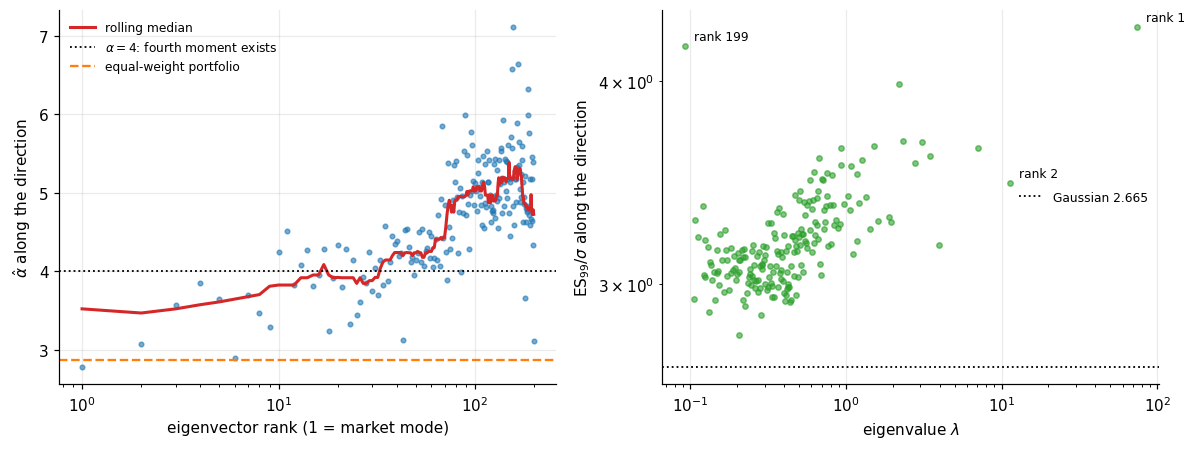

,lambda,alpha,ES99/sd,"kappa(1,30)"
rank,,,,
1,73.6366,2.7745,4.3204,0.1884
2,11.3753,3.0676,3.4634,0.1313
3,7.1038,3.5746,3.6407,0.1442
4,3.9862,3.8492,3.1711,0.0777
5,3.4642,3.6459,3.5962,0.1400
10,1.9509,4.2435,3.2781,0.0658
25,0.9292,3.4439,3.5538,0.0940
50,0.6480,4.1416,3.2614,0.0394
100,0.4008,5.1256,2.9631,0.0490


lambda_1 = 73.6 of 199  (37% of the trace)
median alpha over ranks 10-150 : 4.714
alpha of the market mode        : 2.775
alpha of the smallest direction : 3.110


In [23]:
Xs4 = (A4 - A4.mean(axis=1, keepdims=True)) / A4.std(axis=1, keepdims=True)
lam4, U4v = eigh_desc(sample_cov(Xs4))
proj = U4v.T @ Xs4                                   # (N, T): each row is one eigen-direction

spec = pd.DataFrame({
    "rank": np.arange(1, N4 + 1),
    "lambda": lam4,
    "alpha": [alpha_of(proj[k]) for k in range(N4)],
    "ES99/sd": [es_sigma_ratio(-proj[k], .01) for k in range(N4)],
}).set_index("rank")
spec["kappa(1,30)"] = [kappa_bootstrap(-proj[k], n=30, n0=1, reps=4_000,
                                       rng=np.random.default_rng(1)) if k in
                       (0,1,2,3,4,9,24,49,99,148,197,198) else np.nan for k in range(N4)]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.semilogx(spec.index, spec["alpha"], "o", ms=3, color=C0, alpha=.6)
ax1.semilogx(spec.index, spec["alpha"].rolling(15, center=True, min_periods=3).median(),
             color=C3, lw=2, label="rolling median")
ax1.axhline(4, color="k", ls=":", lw=1.2, label=r"$\alpha=4$: fourth moment exists")
ax1.axhline(alpha_of(A4.mean(axis=0)), color=C1, ls="--", lw=1.5,
            label="equal-weight portfolio")
ax1.set(xlabel="eigenvector rank (1 = market mode)", ylabel=r"$\hat\alpha$ along the direction")
ax1.legend(fontsize=8)
ax2.loglog(spec["lambda"], spec["ES99/sd"], "o", ms=3.5, color=C2, alpha=.6)
ax2.axhline(GAUSS_ES_SD, color="k", ls=":", lw=1.2, label="Gaussian 2.665")
for rk in (1, 2, 199):
    ax2.annotate(f"rank {rk}", (spec.loc[rk, "lambda"], spec.loc[rk, "ES99/sd"]),
                 fontsize=8, xytext=(6, 4), textcoords="offset points")
ax2.set(xlabel=r"eigenvalue $\lambda$", ylabel=r"$\mathrm{ES}_{99}/\sigma$ along the direction")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

show = spec.loc[[1, 2, 3, 4, 5, 10, 25, 50, 100, 149, 198, 199]]
display(show.round(4))
print(f"lambda_1 = {lam4[0]:.1f} of {N4}  ({100*lam4[0]/N4:.0f}% of the trace)")
print(f"median alpha over ranks 10-150 : {spec['alpha'].iloc[9:150].median():.3f}")
print(f"alpha of the market mode        : {spec.loc[1,'alpha']:.3f}")
print(f"alpha of the smallest direction : {spec.loc[N4,'alpha']:.3f}")

So first of all we see that **the tail exponent is not constant across the spectrum**. We are most likely not out of MRV domain. I would just bet that as per usual the preasymptotic is trying to trick us! Though, again, great plots!

Having said that, what are the findings?

1. **The market mode is the fattest direction in the panel**. We obtain $\alpha = 2.78$, the lowest of all $199$, with the worst $\mathrm{ES}_{99}/\sigma$. It also carries $37\%$ of the trace. Thus, the single direction no long-only equity portfolio can avoid is also the one with the heaviest tail. 

2. **The middle of the spectrum is comparatively thin**. Indeed, Ranks 10 through 150 have a median $\alpha$ of $4.71$, with $\mathrm{ES}_{99}/\sigma \approx 3.1$ and $\kappa \approx 0.05$. These are the long-short sector and style directions, and they are where whatever tail-safety exists in this panel lives.

3. **The tail exponent turns fat again at the very bottom.** Rank 199 has $\alpha = 3.11$ and $\mathrm{ES}_{99}/\sigma = 4.21$ — nearly as bad as the market mode, with a direction carrying $0.09$ of the trace. 

How solid are these results though? 

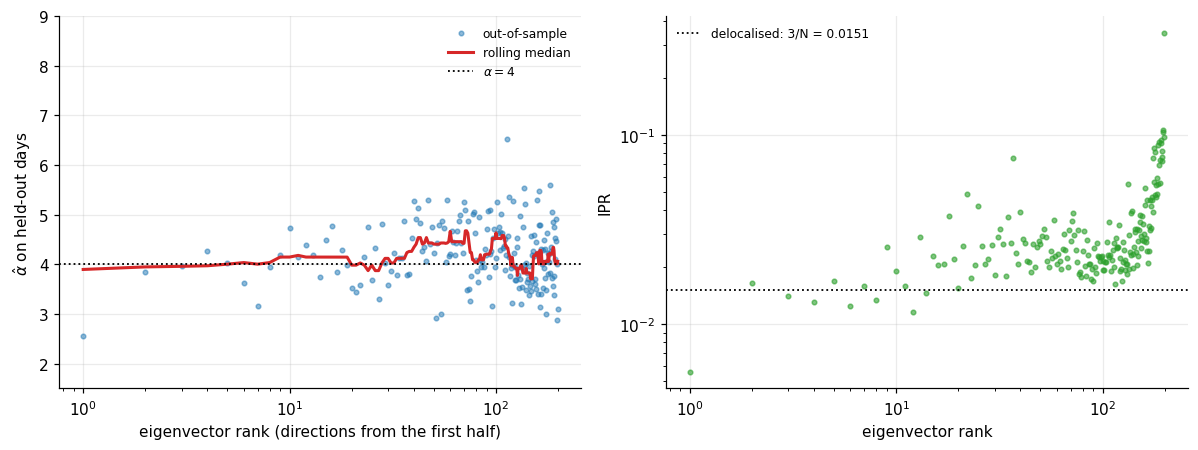

,lambda,IPR,alpha in-sample,alpha OUT-of-sample,ES99/sd OUT,top 3 names
rank,,,,,,
1,73.6366,0.0056,3.5525,2.5659,4.5822,"PRU, BRK-B, ITW"
2,11.3753,0.0164,3.8643,3.8451,3.5252,"ED, WEC, DUK"
3,7.1038,0.0141,5.0524,3.9713,3.2366,"XOM, COP, SNPS"
5,3.4642,0.0169,4.6990,4.0355,3.4508,"EOG, COP, DVN"
10,1.9509,0.0191,5.0719,4.7237,3.4291,"NOC, LMT, GD"
25,0.9292,0.0418,5.8427,3.6872,3.1899,"CMG, KR, NFLX"
50,0.6480,0.0265,4.8332,4.2335,3.2306,"AMD, TGT, YUM"
100,0.4008,0.0216,7.7934,4.1242,3.5149,"SCHW, ABT, FCX"
150,0.2433,0.0316,8.0056,4.1839,3.1876,"MET, PEG, PRU"


correlation between in-sample and out-of-sample alpha across all 199 ranks: -0.058
median alpha out-of-sample — rank 1: 2.57 | ranks 10-150: 4.21 | rank 199: 3.11


In [125]:
# CHECKS
# (1) localisation: is a "direction" a diversified combination, or two stocks?
ipr = np.sum(U4v ** 4, axis=0)                     # inverse participation ratio; 3/N if delocalised
# (2) persistence: estimate directions on the FIRST half, measure tails on the SECOND half.
half = T4 // 2
def stdz(M): return (M - M.mean(axis=1, keepdims=True)) / M.std(axis=1, keepdims=True)
Xs_a, Xs_b = stdz(A4[:, :half]), stdz(A4[:, half:])
lam_a, U_a = eigh_desc(sample_cov(Xs_a))
P_in, P_out = U_a.T @ Xs_a, U_a.T @ Xs_b          # same directions, disjoint days

rows = []
for rk in (1, 2, 3, 5, 10, 25, 50, 100, 150, 190, 198, 199):
    k = rk - 1
    top = list(Xp4.columns[np.argsort(-np.abs(U4v[:, k]))[:3]])
    rows.append({"rank": rk, "lambda": lam4[k], "IPR": ipr[k],
                 "alpha in-sample": alpha_of(P_in[k]), "alpha OUT-of-sample": alpha_of(P_out[k]),
                 "ES99/sd OUT": es_sigma_ratio(-P_out[k], .01),
                 "top 3 names": ", ".join(top)})
val = pd.DataFrame(rows).set_index("rank")
a_in = np.array([alpha_of(P_in[k]) for k in range(N4)])
a_out = np.array([alpha_of(P_out[k]) for k in range(N4)])

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.semilogx(np.arange(1, N4 + 1), a_out, "o", ms=3, color=C0, alpha=.5, label="out-of-sample")
ax1.semilogx(np.arange(1, N4 + 1),
             pd.Series(a_out).rolling(15, center=True, min_periods=3).median(),
             color=C3, lw=2, label="rolling median")
ax1.axhline(4, color="k", ls=":", lw=1.2, label=r"$\alpha=4$")
ax1.set(xlabel="eigenvector rank (directions from the first half)",
        ylabel=r"$\hat\alpha$ on held-out days", ylim=(1.5, 9))
ax1.legend(fontsize=8)
ax2.semilogx(np.arange(1, N4 + 1), ipr, "o", ms=3, color=C2, alpha=.6)
ax2.axhline(3 / N4, color="k", ls=":", lw=1.2, label=f"delocalised: 3/N = {3/N4:.4f}")
ax2.set(xlabel="eigenvector rank", ylabel="IPR", yscale="log")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(val.round(4))
print(f"correlation between in-sample and out-of-sample alpha across all {N4} ranks: "
      f"{np.corrcoef(a_in, a_out)[0, 1]:+.3f}")
print(f"median alpha out-of-sample — rank 1: {a_out[0]:.2f} | ranks 10-150: "
      f"{np.median(a_out[9:150]):.2f} | rank {N4}: {a_out[-1]:.2f}")

What do we have in the above plots? In the left panel we look at the tail exponents measured along the directions estimated with a disjoint set of data (half of the original sample). In the right plot we instead look at the inverse partecipation ratio (IPR) $\sum_i u_{ik}^4$ for our spectrum to investigate how much of an *actual* direction the noisiest part of spectrum gives (from [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails) we know already that is not going to be much, but better to be remined of that).

What do we get then? What can we infer?

1. **The coarse shape of $\hat{\alpha}(\lambda)$ survives**. To wit, the market mode is still the fattest thing in the panel out of sample, the middle is still markedly thinner, and the extreme ranks are still worse than the middle on $\mathrm{ES}_{99}/\sigma$. However, the correlation between in-sample and out-of-sample $\hat\alpha$ across all $199$ ranks is $\mathbf{-0.06}$. Hence, we may say "the top and the bottom of the spectrum are fat and the middle is thin" but *not* that "direction $47$ is fat". 

2. **The "noisy" directions are not direction but pair spreads**. The IPR is $3/N = 0.015$ for a delocalised vector and rises toward $1$ as a vector concentrates on a single name. The rank 1 eigenvector sits at $0.0056$ — i.e., *below* the delocalised value, spread even more evenly than random. But **rank 199 sits at $0.346$, twenty-three times the delocalised value**, and its three largest loadings are PRU, MET and WEC. That is not a direction of the panel. **It is a Prudential-versus-MetLife pair spread**. Additionally, rank $198$, the homebuilder twins LEN/DHI, has $\hat\alpha = 5.93$ in sample: *thin*.Therefore, the bottom of the spectrum is not uniformly fat. It is a collection of localised pair trades, some of which are fat and some of which are not..